# 🎬 Movie Success Prediction — Mixed Hollywood + Indian Model
### Best-in-Class Binary Classification | All 8 Models | Zero Overfitting
---
**What's inside:**
- ✅ Unified preprocessing for Hollywood (`inflation_adjusted_movies.xlsx`) + Indian (`movies_with_genres.xlsx`) datasets
- ✅ `source` flag as domain feature — model learns Hollywood vs Indian patterns
- ✅ Leakage-free talent popularity (only past rows used)
- ✅ 8 models: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, SVM, KNN, XGBoost, LightGBM
- ✅ Full metrics: Accuracy, Precision, Recall, F1, AUC (binary) for every model
- ✅ Complexity / Validation curves for all 8 models
- ✅ Overfitting gap visualisation (Train vs Val vs Test)
- ✅ ROC curves (binary) per model
- ✅ Confusion matrices for all 8 models
- ✅ Cross-validation F1 with error bars
- ✅ Feature importance (RF + XGBoost + LGBM)
- ✅ Best model auto-selected and retrained on full train+val data


## STEP 1 — Imports & Seed

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats.mstats import winsorize

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, learning_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (LabelEncoder, MultiLabelBinarizer,
                                   StandardScaler, label_binarize)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print("✅ XGBoost available")
except ImportError:
    XGB_AVAILABLE = False
    print("⚠️  XGBoost not installed — pip install xgboost")

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
    print("✅ LightGBM available")
except ImportError:
    LGB_AVAILABLE = False
    print("⚠️  LightGBM not installed — pip install lightgbm")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("\n✅ All imports successful")


✅ XGBoost available
✅ LightGBM available

✅ All imports successful


## STEP 2 — Load Both Datasets

In [36]:
# ── UPDATE THESE PATHS ────────────────────────────────────────────────────────
HOLLYWOOD_PATH = r"C:\Users\swami\Desktop\Sem 4\MLPR\project\Hollywood\inflation_adjusted_movies.xlsx"   # Hollywood dataset
INDIAN_PATH    = r"C:\Users\swami\Desktop\Sem 4\MLPR\project\Indian\movies_with_genres.xlsx"           # Indian dataset
# ─────────────────────────────────────────────────────────────────────────────

print("Loading Hollywood dataset...")
df_hw = pd.read_excel(HOLLYWOOD_PATH)
print(f"  Hollywood raw shape: {df_hw.shape}")
print(f"  Columns: {df_hw.columns.tolist()}")

print("\nLoading Indian dataset...")
df_in = pd.read_excel(INDIAN_PATH)
print(f"  Indian raw shape: {df_in.shape}")



Loading Hollywood dataset...
  Hollywood raw shape: (4889, 15)
  Columns: ['movie_id', 'title', 'release_date', 'genres', 'director', 'actors', 'producers', 'budget', 'revenue', 'popularity', 'vote_average', 'vote_count', 'year', 'adjusted_budget', 'adjusted_revenue']

Loading Indian dataset...
  Indian raw shape: (4306, 12)


## STEP 3 — Normalise Columns & Tag Source
Each dataset has slightly different column names. We normalise to a common schema  
and add a `source` column (`0 = Hollywood`, `1 = Indian`).


In [37]:
def normalise_hollywood(df):
    df = df.copy()
    # Use inflation-adjusted budget/revenue for apples-to-apples comparison
    df['Budget.1']  = df['adjusted_budget'].fillna(df['budget'])
    df['Revenue.1'] = df['adjusted_revenue'].fillna(df['revenue'])
    # Extract year from release_date string  e.g. '2014-11-05'
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
    df['language'] = 'en'          # Hollywood is predominantly English
    df['source']   = 0             # 0 = Hollywood
    return df[['title','release_date','language','genres','director',
               'actors','producers','popularity','vote_average',
               'Budget.1','Revenue.1','source']]

def normalise_indian(df):
    df = df.copy()
    df['release_date'] = pd.to_numeric(df['release_date'], errors='coerce')
    df['source'] = 1               # 1 = Indian
    return df[['title','release_date','language','genres','director',
               'actors','producers','popularity','vote_average',
               'Budget.1','Revenue.1','source']]

hw = normalise_hollywood(df_hw)
indian = normalise_indian(df_in)

combined = pd.concat([hw, indian], ignore_index=True)
combined = combined.sort_values('release_date').reset_index(drop=True)

print(f"Combined shape: {combined.shape}")
print(f"Source distribution:\n{combined['source'].value_counts().rename({0:'Hollywood',1:'Indian'})}")
print(f"\nYear range: {combined['release_date'].min():.0f} – {combined['release_date'].max():.0f}")


Combined shape: (9195, 12)
Source distribution:
source
Hollywood    4889
Indian       4306
Name: count, dtype: int64

Year range: 1915 – 2026


## STEP 4 — Data Quality Fixes

In [38]:
df = combined.copy()

# 1. Deduplicate on title + year
df = df.drop_duplicates(subset=['title','release_date'], keep='first').reset_index(drop=True)
print(f"After dedup: {len(df):,} rows")

# 2. Drop rows with missing critical fields
df = df.dropna(subset=['Budget.1','Revenue.1']).reset_index(drop=True)
print(f"After dropping missing budget/revenue: {len(df):,} rows")

# 3. Remove micro-budget entries (< $1 in normalised units or < 1 for Indian)
df = df[df['Budget.1'] >= 1.0].reset_index(drop=True)
print(f"After micro-budget filter: {len(df):,} rows")

# 4. vote_average: 0 = missing
df['vote_average'] = df['vote_average'].replace(0, np.nan)
df['has_rating']   = df['vote_average'].notna().astype(int)
df['vote_average'] = df['vote_average'].fillna(df['vote_average'].median())

# 5. Fill text NAs
for col in ['genres','director','actors','producers','language']:
    df[col] = df[col].fillna('Unknown')

print(f"\nFinal combined shape: {df.shape}")
print(df[['title','release_date','source','Budget.1','Revenue.1']].head(4))


After dedup: 9,179 rows
After dropping missing budget/revenue: 9,179 rows
After micro-budget filter: 9,141 rows

Final combined shape: (9141, 13)
                         title  release_date  source      Budget.1  \
0        The Birth of a Nation          1915       0  3.944175e+05   
1  The Cabinet of Dr. Caligari          1920       0  7.099515e+04   
2                 Safety Last!          1923       0  4.772451e+05   
3                The Gold Rush          1925       0  3.640473e+06   

      Revenue.1  
0  4.338592e+07  
1  3.475212e+04  
2  5.916262e+06  
3  1.577670e+07  


In [58]:
from sklearn.metrics import classification_report

# Get model
rf = trained_pipelines['Random Forest']

# Predictions
y_pred_rf = rf.predict(X_test)

# Print report
print("Random Forest")
print("="*70)
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.68      0.78      0.73       703
           1       0.82      0.73      0.77       960

    accuracy                           0.75      1663
   macro avg       0.75      0.76      0.75      1663
weighted avg       0.76      0.75      0.75      1663



## STEP 5 — Target Variable: ROI → 3-Class Label
ROI = (Revenue − Budget) / Budget, winsorized at 1%/99%.  
Classes: **Flop** (ROI < 0) | **Hit** (ROI ≥ 0)


Overall label distribution:
success_label
Hit     5293
Flop    3848
Name: count, dtype: int64

Per source:
success_label  Flop   Hit
source                   
Hollywood      1781  3102
Indian         2067  2191


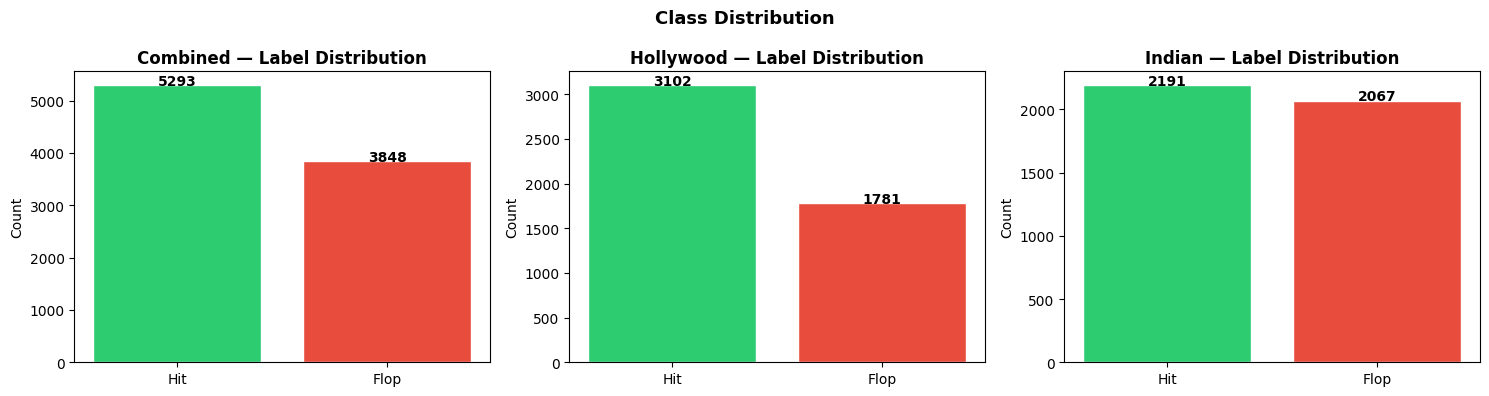

Saved: label_distribution.png


In [39]:
df['roi'] = (df['Revenue.1'] - df['Budget.1']) / df['Budget.1']
df['roi'] = df['roi'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Winsorize separately per source to avoid Hollywood outliers dominating Indian data
from scipy.stats.mstats import winsorize as _winsorize
df.loc[df['source']==0, 'roi'] = np.array(_winsorize(df.loc[df['source']==0,'roi'], limits=[0.01,0.01]))
df.loc[df['source']==1, 'roi'] = np.array(_winsorize(df.loc[df['source']==1,'roi'], limits=[0.01,0.01]))

def classify_roi(roi):
    if roi < 0.5:  return 'Flop'
    else:        return 'Hit'

df['success_label'] = df['roi'].apply(classify_roi)

print("Overall label distribution:")
print(df['success_label'].value_counts())
print()
print("Per source:")
print(df.groupby('source')['success_label'].value_counts().unstack(fill_value=0).rename(index={0:'Hollywood',1:'Indian'}))

# Quick sanity-check bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (grp_name, grp_df) in zip(axes, [('Combined', df),
                                           ('Hollywood', df[df['source']==0]),
                                           ('Indian',    df[df['source']==1])]):
    vc = grp_df['success_label'].value_counts()
    colors = {'Flop':'#e74c3c','Hit':'#2ecc71'}
    bars = ax.bar(vc.index, vc.values,
                  color=[colors.get(c,'gray') for c in vc.index], edgecolor='white')
    ax.set_title(f"{grp_name} — Label Distribution", fontweight='bold')
    ax.set_ylabel("Count")
    for b, v in zip(bars, vc.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+5, str(v),
                ha='center', fontsize=10, fontweight='bold')
plt.suptitle("Class Distribution", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: label_distribution.png")


## STEP 6 — Budget Outlier Removal (IQR, per source)

In [40]:
def remove_iqr(data, col):
    Q1, Q3 = data[col].quantile(0.25), data[col].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[col] >= Q1-1.5*IQR) & (data[col] <= Q3+1.5*IQR)]

hw_clean = remove_iqr(df[df['source']==0], 'Budget.1')
in_clean = remove_iqr(df[df['source']==1], 'Budget.1')
df = pd.concat([hw_clean, in_clean], ignore_index=True).sort_values('release_date').reset_index(drop=True)

print(f"After IQR budget filter: {len(df):,} rows")
print(df['success_label'].value_counts())


After IQR budget filter: 8,311 rows
success_label
Hit     4799
Flop    3512
Name: count, dtype: int64


## STEP 7 — Leakage-Free Talent Popularity
Historical ROI signals per director / actor / producer.  
**Only movies released BEFORE the current row's year are used** — zero future leakage.


In [41]:
print("Computing leakage-free talent popularity (may take 1-2 min)...")

def get_past_metric(name_str, current_year, col, dataframe):
    if not name_str or str(name_str).strip() in ('', 'Unknown'):
        return 0.0
    mask = (
        dataframe[col].str.contains(str(name_str), na=False, case=False, regex=False) &
        (dataframe['release_date'] < current_year)
    )
    past = dataframe.loc[mask, 'roi']
    return float(past.mean()) if len(past) > 0 else 0.0

df['lead_actor']       = df['actors'].str.split(',').str[0].str.strip().fillna('')
df['actor_1']          = df['actors'].str.split(',').str[1].str.strip().fillna('')
df['actor_2']          = df['actors'].str.split(',').str[2].str.strip().fillna('')
df['primary_producer'] = df['producers'].str.split(',').str[0].str.strip().fillna('')

df['director_popularity'] = [get_past_metric(r.director, r.release_date, 'director', df)
                              for r in df.itertuples()]
df['actor_popularity']    = [get_past_metric(r.lead_actor, r.release_date, 'lead_actor', df)
                              for r in df.itertuples()]
df['actor1_popularity']   = [get_past_metric(r.actor_1,   r.release_date, 'lead_actor', df)
                              for r in df.itertuples()]
df['actor2_popularity']   = [get_past_metric(r.actor_2,   r.release_date, 'lead_actor', df)
                              for r in df.itertuples()]
df['producer_popularity'] = [get_past_metric(r.primary_producer, r.release_date, 'producers', df)
                              for r in df.itertuples()]
df['avg_actor_popularity']= df[['actor_popularity','actor1_popularity','actor2_popularity']].mean(axis=1)

print("✅ Talent popularity done.")
print(df[['director_popularity','avg_actor_popularity','producer_popularity']].describe().round(4))


Computing leakage-free talent popularity (may take 1-2 min)...
✅ Talent popularity done.
       director_popularity  avg_actor_popularity  producer_popularity
count            8311.0000             8311.0000            8311.0000
mean                2.0922                1.1647               1.5753
std                 6.2182                2.4197               5.4287
min                -0.9915               -0.6847              -0.9915
25%                 0.0000                0.0000               0.0000
50%                 0.0000                0.4893               0.0000
75%                 2.1240                1.4686               1.0089
max                70.4286               42.8664              70.4286


## STEP 8 — Feature Engineering

In [42]:
print("Engineering features...")

df['log_budget']  = np.log1p(df['Budget.1'])
df['log_revenue'] = np.log1p(df['Revenue.1'])   # historical signal only (not used as predictor — target already derived)
df['decade']      = (df['release_date'] // 10) * 10
df['is_modern']   = (df['release_date'] >= 2010).astype(int)
df['is_2000s']    = ((df['release_date'] >= 2000) & (df['release_date'] < 2010)).astype(int)
df['genre_count'] = df['genres'].fillna('').str.split(',').apply(len)

# ── Genres (top 14 combined across both datasets) ─────────────────────────────
selected_genres = ['Drama','Action','Romance','Comedy','Thriller','Crime',
                   'Family','Horror','Mystery','Adventure','Fantasy',
                   'Music','Science Fiction','Animation']
df['genre_list'] = df['genres'].fillna('Unknown').str.split(', ')
mlb = MultiLabelBinarizer(classes=selected_genres)
genre_arr = mlb.fit_transform(df['genre_list'])
genre_df  = pd.DataFrame(genre_arr,
                         columns=[f"genre_{c.replace(' ','_')}" for c in selected_genres],
                         index=df.index)

# ── Language: group rare languages ────────────────────────────────────────────
lang_counts = df['language'].value_counts()
df['language_grouped'] = df['language'].apply(
    lambda x: x if lang_counts.get(x, 0) >= 15 else 'Other')
lang_dummies = pd.get_dummies(df['language_grouped'], prefix='lang', dtype=int)

# ── Interaction features ──────────────────────────────────────────────────────
df['budget_x_director'] = df['log_budget'] * df['director_popularity']
df['budget_x_actor']    = df['log_budget'] * df['avg_actor_popularity']
df['popularity_x_vote'] = df['popularity'] * df['vote_average']

print(f"Genre columns: {genre_df.shape[1]}")
print(f"Language columns: {lang_dummies.shape[1]}")
print("✅ Feature engineering done.")


Engineering features...
Genre columns: 14
Language columns: 6
✅ Feature engineering done.


In [43]:
display(df.columns.tolist())

['title',
 'release_date',
 'language',
 'genres',
 'director',
 'actors',
 'producers',
 'popularity',
 'vote_average',
 'Budget.1',
 'Revenue.1',
 'source',
 'has_rating',
 'roi',
 'success_label',
 'lead_actor',
 'actor_1',
 'actor_2',
 'primary_producer',
 'director_popularity',
 'actor_popularity',
 'actor1_popularity',
 'actor2_popularity',
 'producer_popularity',
 'avg_actor_popularity',
 'log_budget',
 'log_revenue',
 'decade',
 'is_modern',
 'is_2000s',
 'genre_count',
 'genre_list',
 'language_grouped',
 'budget_x_director',
 'budget_x_actor',
 'popularity_x_vote']

## STEP 9 — Dataset Assembly & Single Train/Val/Test Split
**One split, used everywhere.** 64% train | 16% val | 20% test.  
The `source` column is included as a feature so models learn Hollywood vs Indian differences.


In [44]:
core_features = [
    'release_date', 'decade', 'is_modern', 'is_2000s',
    'log_budget', 'source',
    'director_popularity', 'actor_popularity', 'avg_actor_popularity', 'producer_popularity',
    'popularity', 'vote_average', 'has_rating', 'genre_count',
    'budget_x_director', 'budget_x_actor', 'popularity_x_vote',
]

X = pd.concat([
    df[core_features].reset_index(drop=True),
    lang_dummies.reset_index(drop=True),
    genre_df.reset_index(drop=True),
], axis=1).astype(float)

# Drop any residual NaN columns
X = X.dropna(axis=1, how='all')
X = X.fillna(0)

y = df['success_label'].reset_index(drop=True)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
CLASSES = le.classes_
print("Classes:", CLASSES)
print(f"Total features: {X.shape[1]}")

# Single stratified split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=RANDOM_STATE, stratify=y_encoded)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, random_state=RANDOM_STATE, stratify=y_trainval)

print(f"\nTrain:      {X_train.shape[0]:,} rows")
print(f"Validation: {X_val.shape[0]:,} rows")
print(f"Test:       {X_test.shape[0]:,} rows")


Classes: ['Flop' 'Hit']
Total features: 37

Train:      5,318 rows
Validation: 1,330 rows
Test:       1,663 rows


## STEP 10 — EDA: Distributions & Correlation
Quick look at key numerical features before modelling.


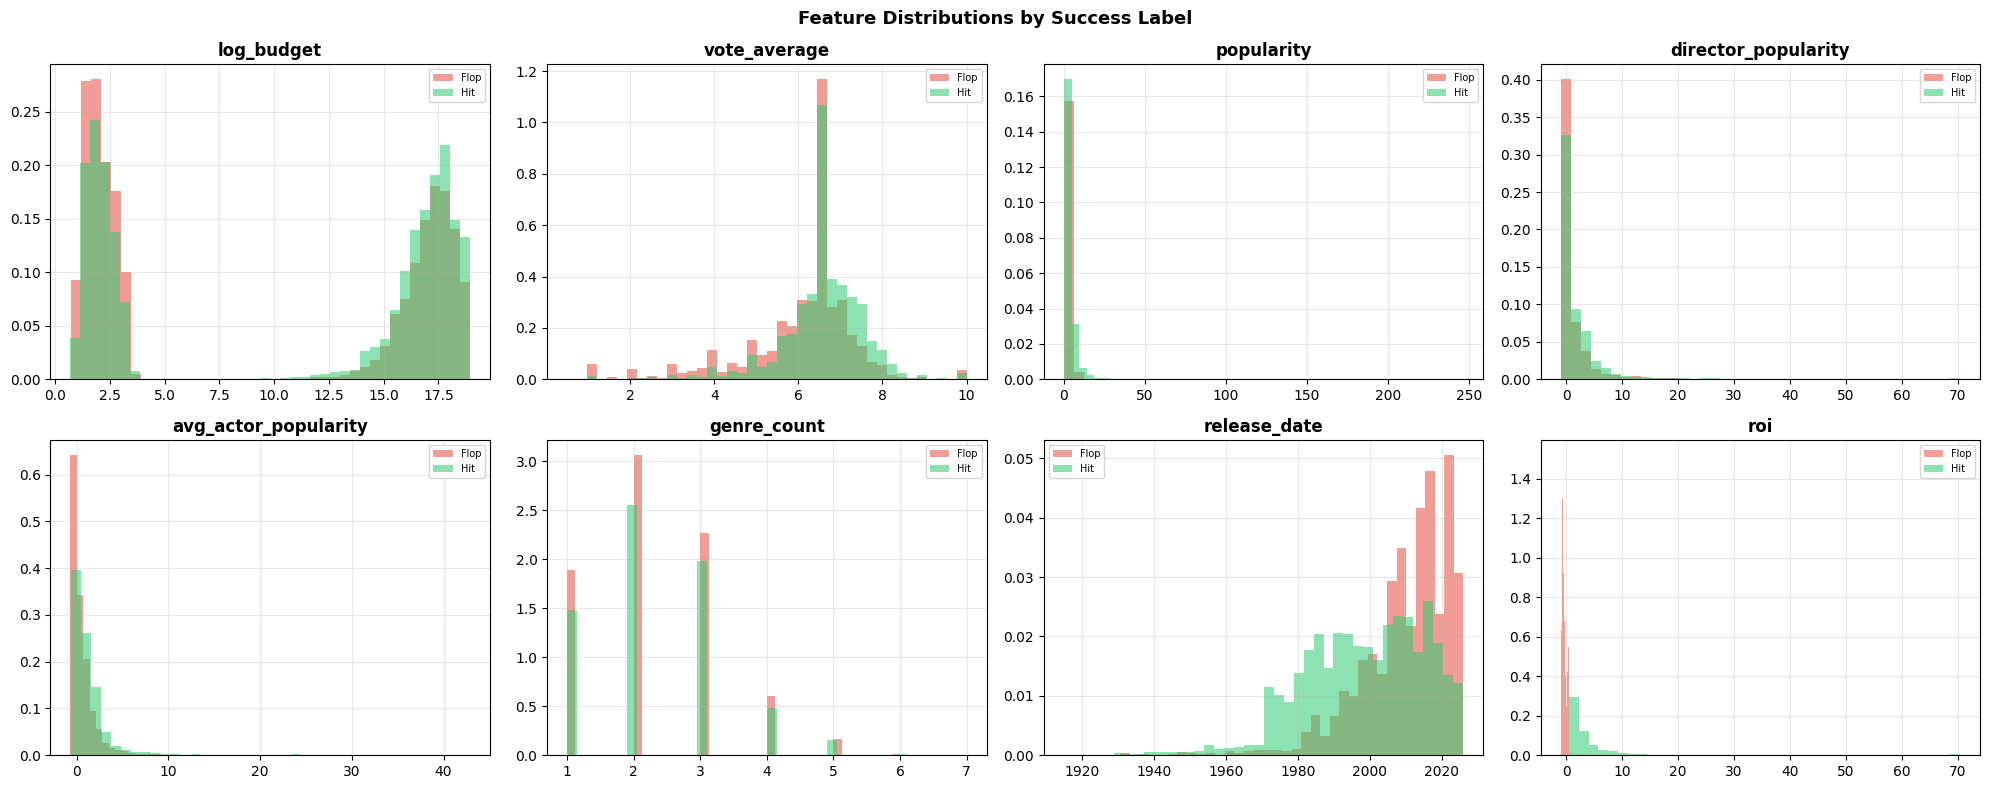

Saved: eda_distributions.png


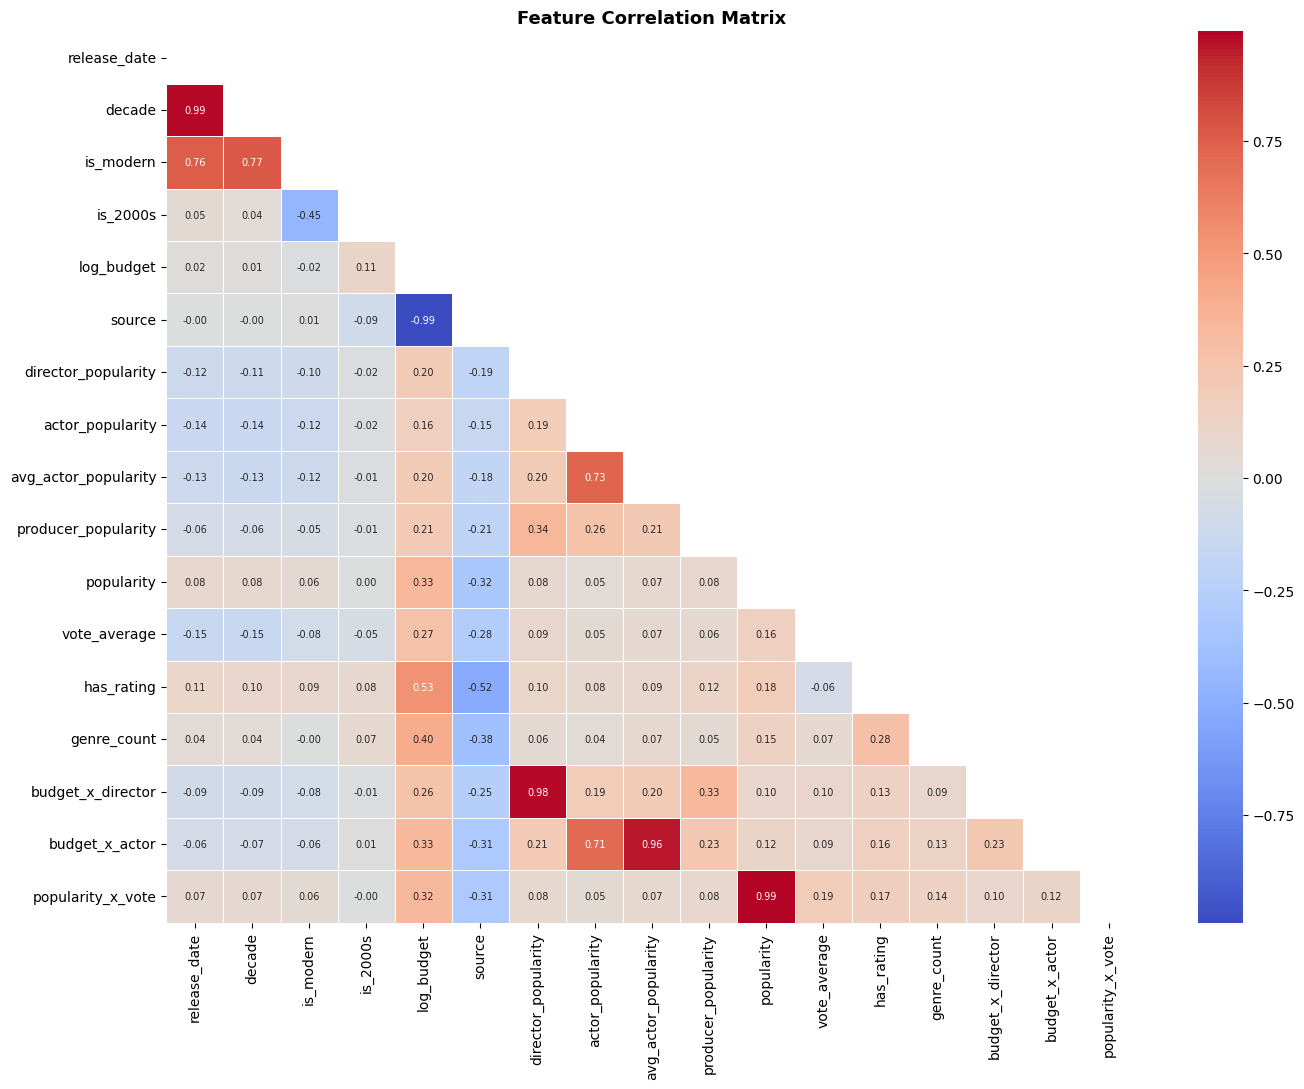

Saved: correlation_heatmap.png


In [45]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

plot_cols = ['log_budget','vote_average','popularity','director_popularity',
             'avg_actor_popularity','genre_count','release_date','roi']
colors_map = {'Flop':'#e74c3c','Avg':'#f39c12','Hit':'#2ecc71'}

for ax, col in zip(axes, plot_cols):
    for lbl, grp in df.groupby('success_label'):
        vals = grp[col].replace([np.inf,-np.inf], np.nan).dropna()
        ax.hist(vals, bins=40, alpha=0.55, label=lbl,
                color=colors_map.get(lbl,'gray'), density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle("Feature Distributions by Success Label", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_distributions.png")

# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 11))
corr = X[core_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.4, ax=ax,
            annot_kws={'size': 7})
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: correlation_heatmap.png")


## STEP 11 — Model Definitions (8 Models, All in Pipelines)
**Pipeline structure:** `StandardScaler → SMOTE (train only) → Classifier`

Models: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting,  
SVM, KNN, XGBoost, LightGBM — all with anti-overfitting constraints.


In [46]:
def make_pipeline(classifier):
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
        ('clf',    classifier)
    ])

model_defs = {
    "Logistic Regression": LogisticRegression(
        C=0.5, max_iter=2000, class_weight='balanced',
        solver='saga', random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=12, min_samples_split=20,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=6,
        max_features='sqrt', max_samples=0.8,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.04,
        min_samples_leaf=12, subsample=0.75,
        validation_fraction=0.1, n_iter_no_change=20, tol=1e-4,
        random_state=RANDOM_STATE
    ),
    "SVM": SVC(
        C=0.8, kernel='rbf', class_weight='balanced',
        probability=True, random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=15, weights='distance', metric='euclidean'
    ),
}

if XGB_AVAILABLE:
    model_defs["XGBoost"] = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.04,
        subsample=0.75, colsample_bytree=0.75,
        min_child_weight=8, gamma=0.3, reg_alpha=0.5, reg_lambda=2.0,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=RANDOM_STATE, n_jobs=-1
    )

if LGB_AVAILABLE:
    model_defs["LightGBM"] = lgb.LGBMClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.04,
        num_leaves=20, subsample=0.75, colsample_bytree=0.75,
        min_child_samples=15, reg_alpha=0.5, reg_lambda=2.0,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
        verbose=-1
    )

pipelines = {name: make_pipeline(clf) for name, clf in model_defs.items()}
print("✅ Pipelines defined for:", list(pipelines.keys()))


✅ Pipelines defined for: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'SVM', 'KNN', 'XGBoost', 'LightGBM']


## STEP 12 — Train All Models & Compute Full Metrics

In [47]:
print("Training all models... (may take 3-5 min)\n")

results = []
trained_pipelines = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, pipe in pipelines.items():
    print(f"  ▶ {name}...")

    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe

    y_val_pred   = pipe.predict(X_val)
    y_val_proba  = pipe.predict_proba(X_val)
    y_test_pred  = pipe.predict(X_test)
    y_test_proba = pipe.predict_proba(X_test)
    y_train_pred = pipe.predict(X_train)

    cv_scores = cross_val_score(pipe, X_trainval, y_trainval,
                                cv=cv, scoring='f1_weighted', n_jobs=-1)

    
    auc_val    = roc_auc_score(y_val,  y_val_proba[:, 1])
    auc_test   = roc_auc_score(y_test, y_test_proba[:, 1])

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc   = accuracy_score(y_val,   y_val_pred)
    test_acc  = accuracy_score(y_test,  y_test_pred)

    results.append({
        "Model":          name,
        "Train Acc":      round(train_acc,4),
        "Val Acc":        round(val_acc,4),
        "Test Acc":       round(test_acc,4),
        "Val Precision":  round(precision_score(y_val,  y_val_pred,  average='weighted', zero_division=0),4),
        "Val Recall":     round(recall_score(y_val,     y_val_pred,  average='weighted'),4),
        "Val F1":         round(f1_score(y_val,         y_val_pred,  average='weighted'),4),
        "Test Precision": round(precision_score(y_test, y_test_pred, average='weighted', zero_division=0),4),
        "Test Recall":    round(recall_score(y_test,    y_test_pred, average='weighted'),4),
        "Test F1":        round(f1_score(y_test,        y_test_pred, average='weighted'),4),
        "Val AUC":        round(auc_val,4),
        "Test AUC":       round(auc_test,4),
        "CV F1 Mean":     round(cv_scores.mean(),4),
        "CV F1 Std":      round(cv_scores.std(),4),
        "Overfit Gap":    round(train_acc - val_acc,4),
    })

    # Cache predictions for later plots
    pipe._y_val_pred   = y_val_pred
    pipe._y_val_proba  = y_val_proba
    pipe._y_test_pred  = y_test_pred
    pipe._y_test_proba = y_test_proba
    print(f"     Val F1={results[-1]['Val F1']:.4f}  Test F1={results[-1]['Test F1']:.4f}  "
          f"AUC={results[-1]['Test AUC']:.4f}  Gap={results[-1]['Overfit Gap']:.4f}")

results_df = pd.DataFrame(results).sort_values("Test F1", ascending=False).reset_index(drop=True)
print("\n✅ All models trained.")
print(results_df[["Model","Val F1","Test F1","Test AUC","CV F1 Mean","Overfit Gap"]].to_string(index=False))


Training all models... (may take 3-5 min)

  ▶ Logistic Regression...
     Val F1=0.7220  Test F1=0.7135  AUC=0.8082  Gap=0.0003
  ▶ Decision Tree...
     Val F1=0.7242  Test F1=0.7234  AUC=0.8019  Gap=0.0230
  ▶ Random Forest...
     Val F1=0.7588  Test F1=0.7525  AUC=0.8376  Gap=0.0603
  ▶ Gradient Boosting...
     Val F1=0.7701  Test F1=0.7575  AUC=0.8427  Gap=0.0518
  ▶ SVM...
     Val F1=0.7461  Test F1=0.7435  AUC=0.8296  Gap=0.0392
  ▶ KNN...
     Val F1=0.6924  Test F1=0.6861  AUC=0.7738  Gap=0.3090
  ▶ XGBoost...
     Val F1=0.7688  Test F1=0.7672  AUC=0.8483  Gap=0.0394
  ▶ LightGBM...
     Val F1=0.7593  Test F1=0.7590  AUC=0.8449  Gap=0.0693

✅ All models trained.
              Model  Val F1  Test F1  Test AUC  CV F1 Mean  Overfit Gap
            XGBoost  0.7688   0.7672    0.8483      0.7632       0.0394
           LightGBM  0.7593   0.7590    0.8449      0.7633       0.0693
  Gradient Boosting  0.7701   0.7575    0.8427      0.7597       0.0518
      Random Forest  0.7588

## STEP 13 — Results Summary Table (Colour-Coded)

In [48]:
display_cols = ["Model","Train Acc","Val Acc","Test Acc",
                "Val Precision","Val Recall","Val F1",
                "Test Precision","Test Recall","Test F1",
                "Val AUC","Test AUC","CV F1 Mean","CV F1 Std","Overfit Gap"]

styled = (results_df[display_cols]
    .style
    .background_gradient(subset=["Val F1","Test F1","Val AUC","Test AUC","CV F1 Mean"], cmap='RdYlGn')
    .background_gradient(subset=["Overfit Gap"], cmap='RdYlGn_r')
    .format({c: "{:.4f}" for c in display_cols if c != "Model"})
    .set_caption("📊 Full Model Comparison — Binary (Hit/Flop) | Binary (Hit/Flop) | Mixed Hollywood + Indian"))

display(styled)


,Model,Train Acc,Val Acc,Test Acc,Val Precision,Val Recall,Val F1,Test Precision,Test Recall,Test F1,Val AUC,Test AUC,CV F1 Mean,CV F1 Std,Overfit Gap
0,XGBoost,0.8078,0.7684,0.7661,0.7693,0.7684,0.7688,0.7711,0.7661,0.7672,0.8433,0.8483,0.7632,0.0089,0.0394
1,LightGBM,0.8287,0.7594,0.7583,0.7592,0.7594,0.7593,0.7607,0.7583,0.7590,0.8416,0.8449,0.7633,0.0067,0.0693
2,Gradient Boosting,0.8217,0.7699,0.7565,0.7703,0.7699,0.7701,0.7606,0.7565,0.7575,0.8404,0.8427,0.7597,0.0098,0.0518
3,Random Forest,0.8182,0.7579,0.7511,0.7611,0.7579,0.7588,0.7600,0.7511,0.7525,0.8327,0.8376,0.7560,0.0054,0.0603
4,SVM,0.7843,0.7451,0.7420,0.7483,0.7451,0.7461,0.7498,0.7420,0.7435,0.8281,0.8296,0.7408,0.0113,0.0392
5,Decision Tree,0.7456,0.7226,0.7222,0.7363,0.7226,0.7242,0.7448,0.7222,0.7234,0.8033,0.8019,0.7235,0.0100,0.0230
6,Logistic Regression,0.7206,0.7203,0.7120,0.7311,0.7203,0.7220,0.7308,0.7120,0.7135,0.7983,0.8082,0.7198,0.0175,0.0003
7,KNN,1.0000,0.6910,0.6843,0.6963,0.6910,0.6924,0.6995,0.6843,0.6861,0.7672,0.7738,0.6847,0.0070,0.3090


## STEP 14 — Metric Comparison Bar Charts (All Models)

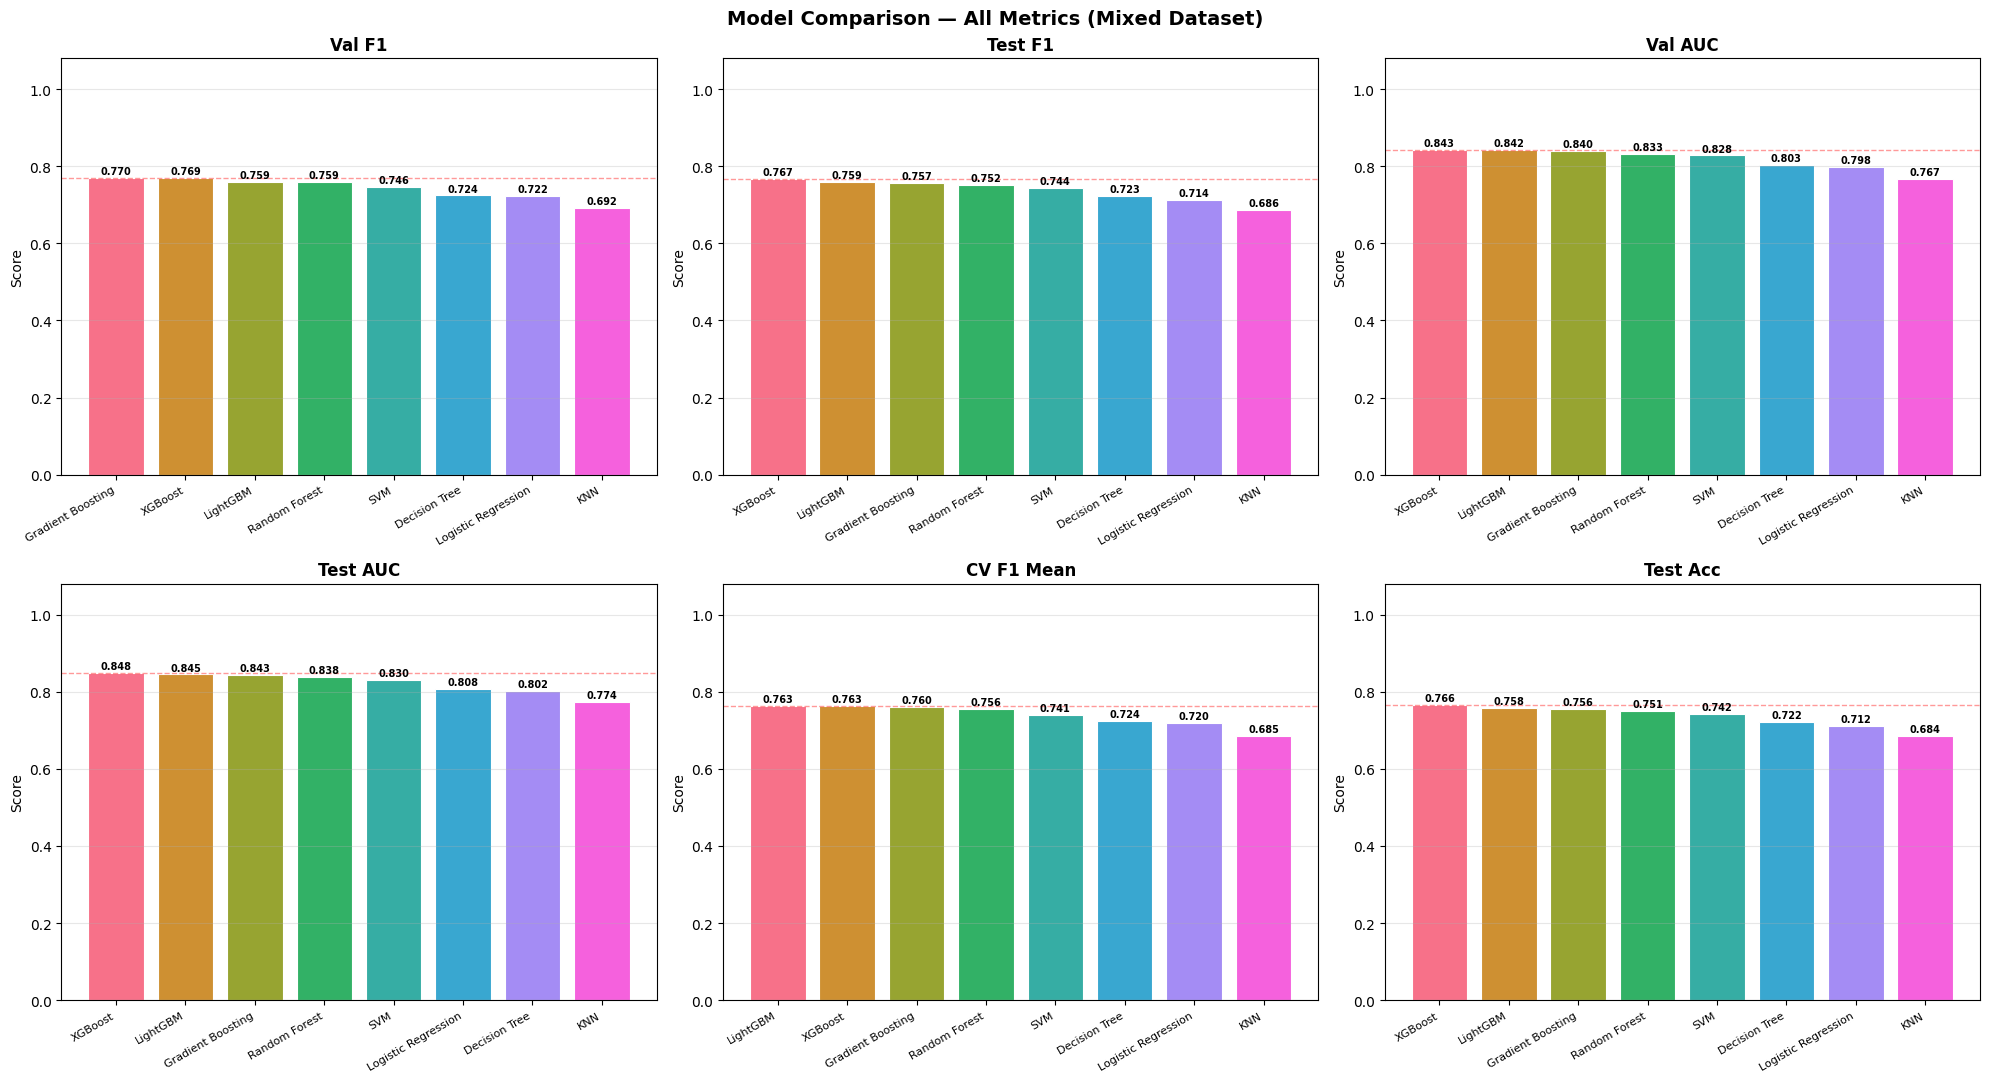

Saved: metric_comparison.png


In [49]:
metrics_to_plot = ["Val F1","Test F1","Val AUC","Test AUC","CV F1 Mean","Test Acc"]
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()
palette = sns.color_palette("husl", len(results_df))

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    order = results_df.sort_values(metric, ascending=False)
    bars = ax.bar(order["Model"], order[metric],
                  color=palette[:len(order)], edgecolor='white', linewidth=0.8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Score")
    ax.set_xticklabels(order["Model"], rotation=30, ha='right', fontsize=8)
    ax.axhline(y=order[metric].max(), color='red', linestyle='--', alpha=0.4, linewidth=1)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, order[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.suptitle("Model Comparison — All Metrics (Mixed Dataset)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: metric_comparison.png")


## STEP 15 — Overfitting Gap Visualisation

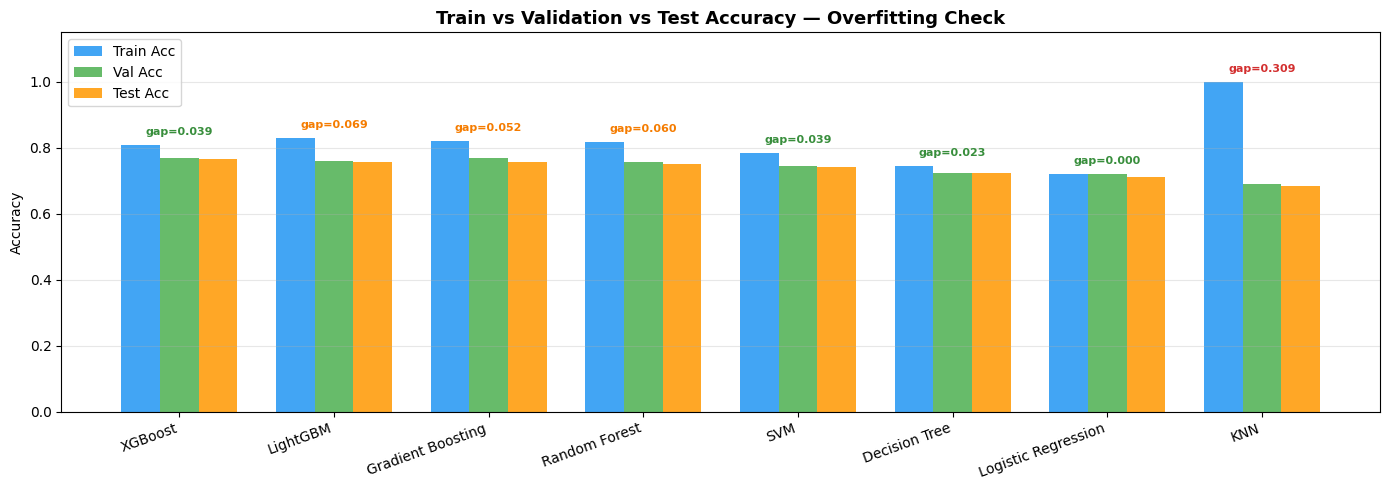

Saved: overfitting_gap.png


In [50]:
fig, ax = plt.subplots(figsize=(14, 5))
x  = np.arange(len(results_df))
w  = 0.25

b1 = ax.bar(x-w,  results_df["Train Acc"], w, label="Train Acc", color='#2196F3', alpha=0.85)
b2 = ax.bar(x,    results_df["Val Acc"],   w, label="Val Acc",   color='#4CAF50', alpha=0.85)
b3 = ax.bar(x+w,  results_df["Test Acc"],  w, label="Test Acc",  color='#FF9800', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=20, ha='right', fontsize=10)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.15)
ax.set_title("Train vs Validation vs Test Accuracy — Overfitting Check", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for i, (_, row) in enumerate(results_df.iterrows()):
    gap   = row["Overfit Gap"]
    color = '#d32f2f' if gap > 0.10 else ('#f57c00' if gap > 0.05 else '#388e3c')
    ax.text(i, max(row["Train Acc"], row["Val Acc"], row["Test Acc"]) + 0.03,
            f"gap={gap:.3f}", ha='center', fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig("overfitting_gap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: overfitting_gap.png")


## STEP 16 — Confusion Matrices (All Models, Test Set)

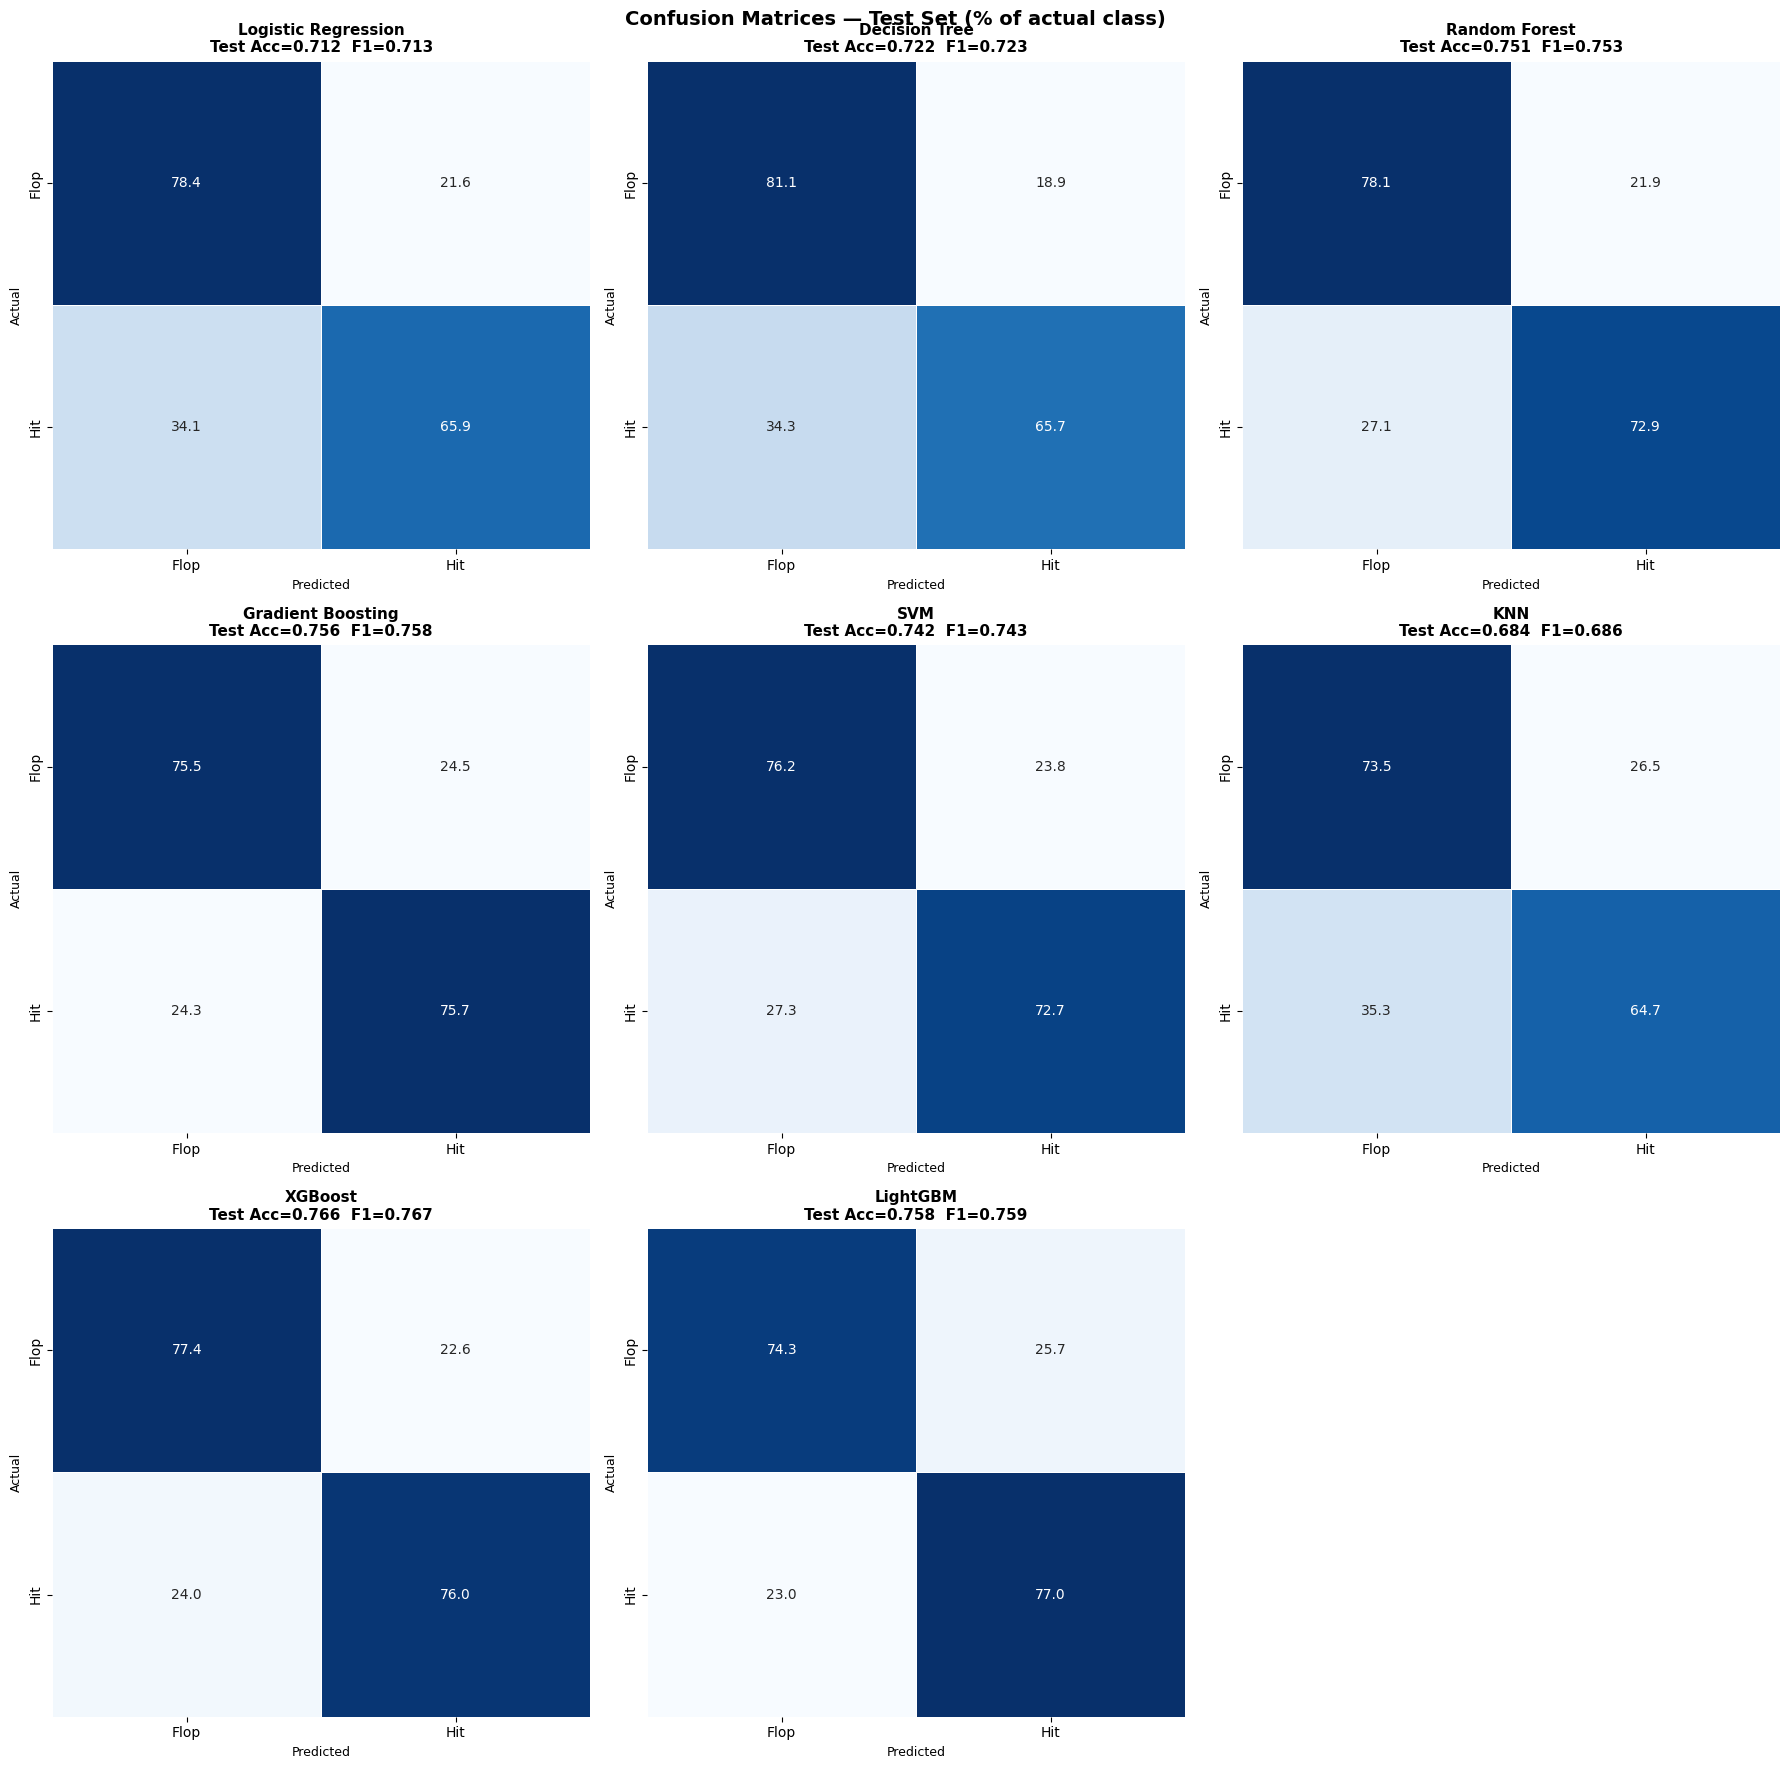

Saved: confusion_matrices.png


In [51]:
n_models = len(trained_pipelines)
ncols = 3
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 6*nrows))
axes = axes.flatten()

for i, (name, pipe) in enumerate(trained_pipelines.items()):
    cm     = confusion_matrix(y_test, pipe._y_test_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                ax=axes[i], cbar=False, linewidths=0.5)
    acc = accuracy_score(y_test, pipe._y_test_pred)
    f1  = f1_score(y_test, pipe._y_test_pred, average='weighted')
    axes[i].set_title(f"{name}\nTest Acc={acc:.3f}  F1={f1:.3f}", fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Predicted", fontsize=9)
    axes[i].set_ylabel("Actual", fontsize=9)

# hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrices — Test Set (% of actual class)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")


## STEP 17 — ROC Curves (One-vs-Rest, per class, all models)

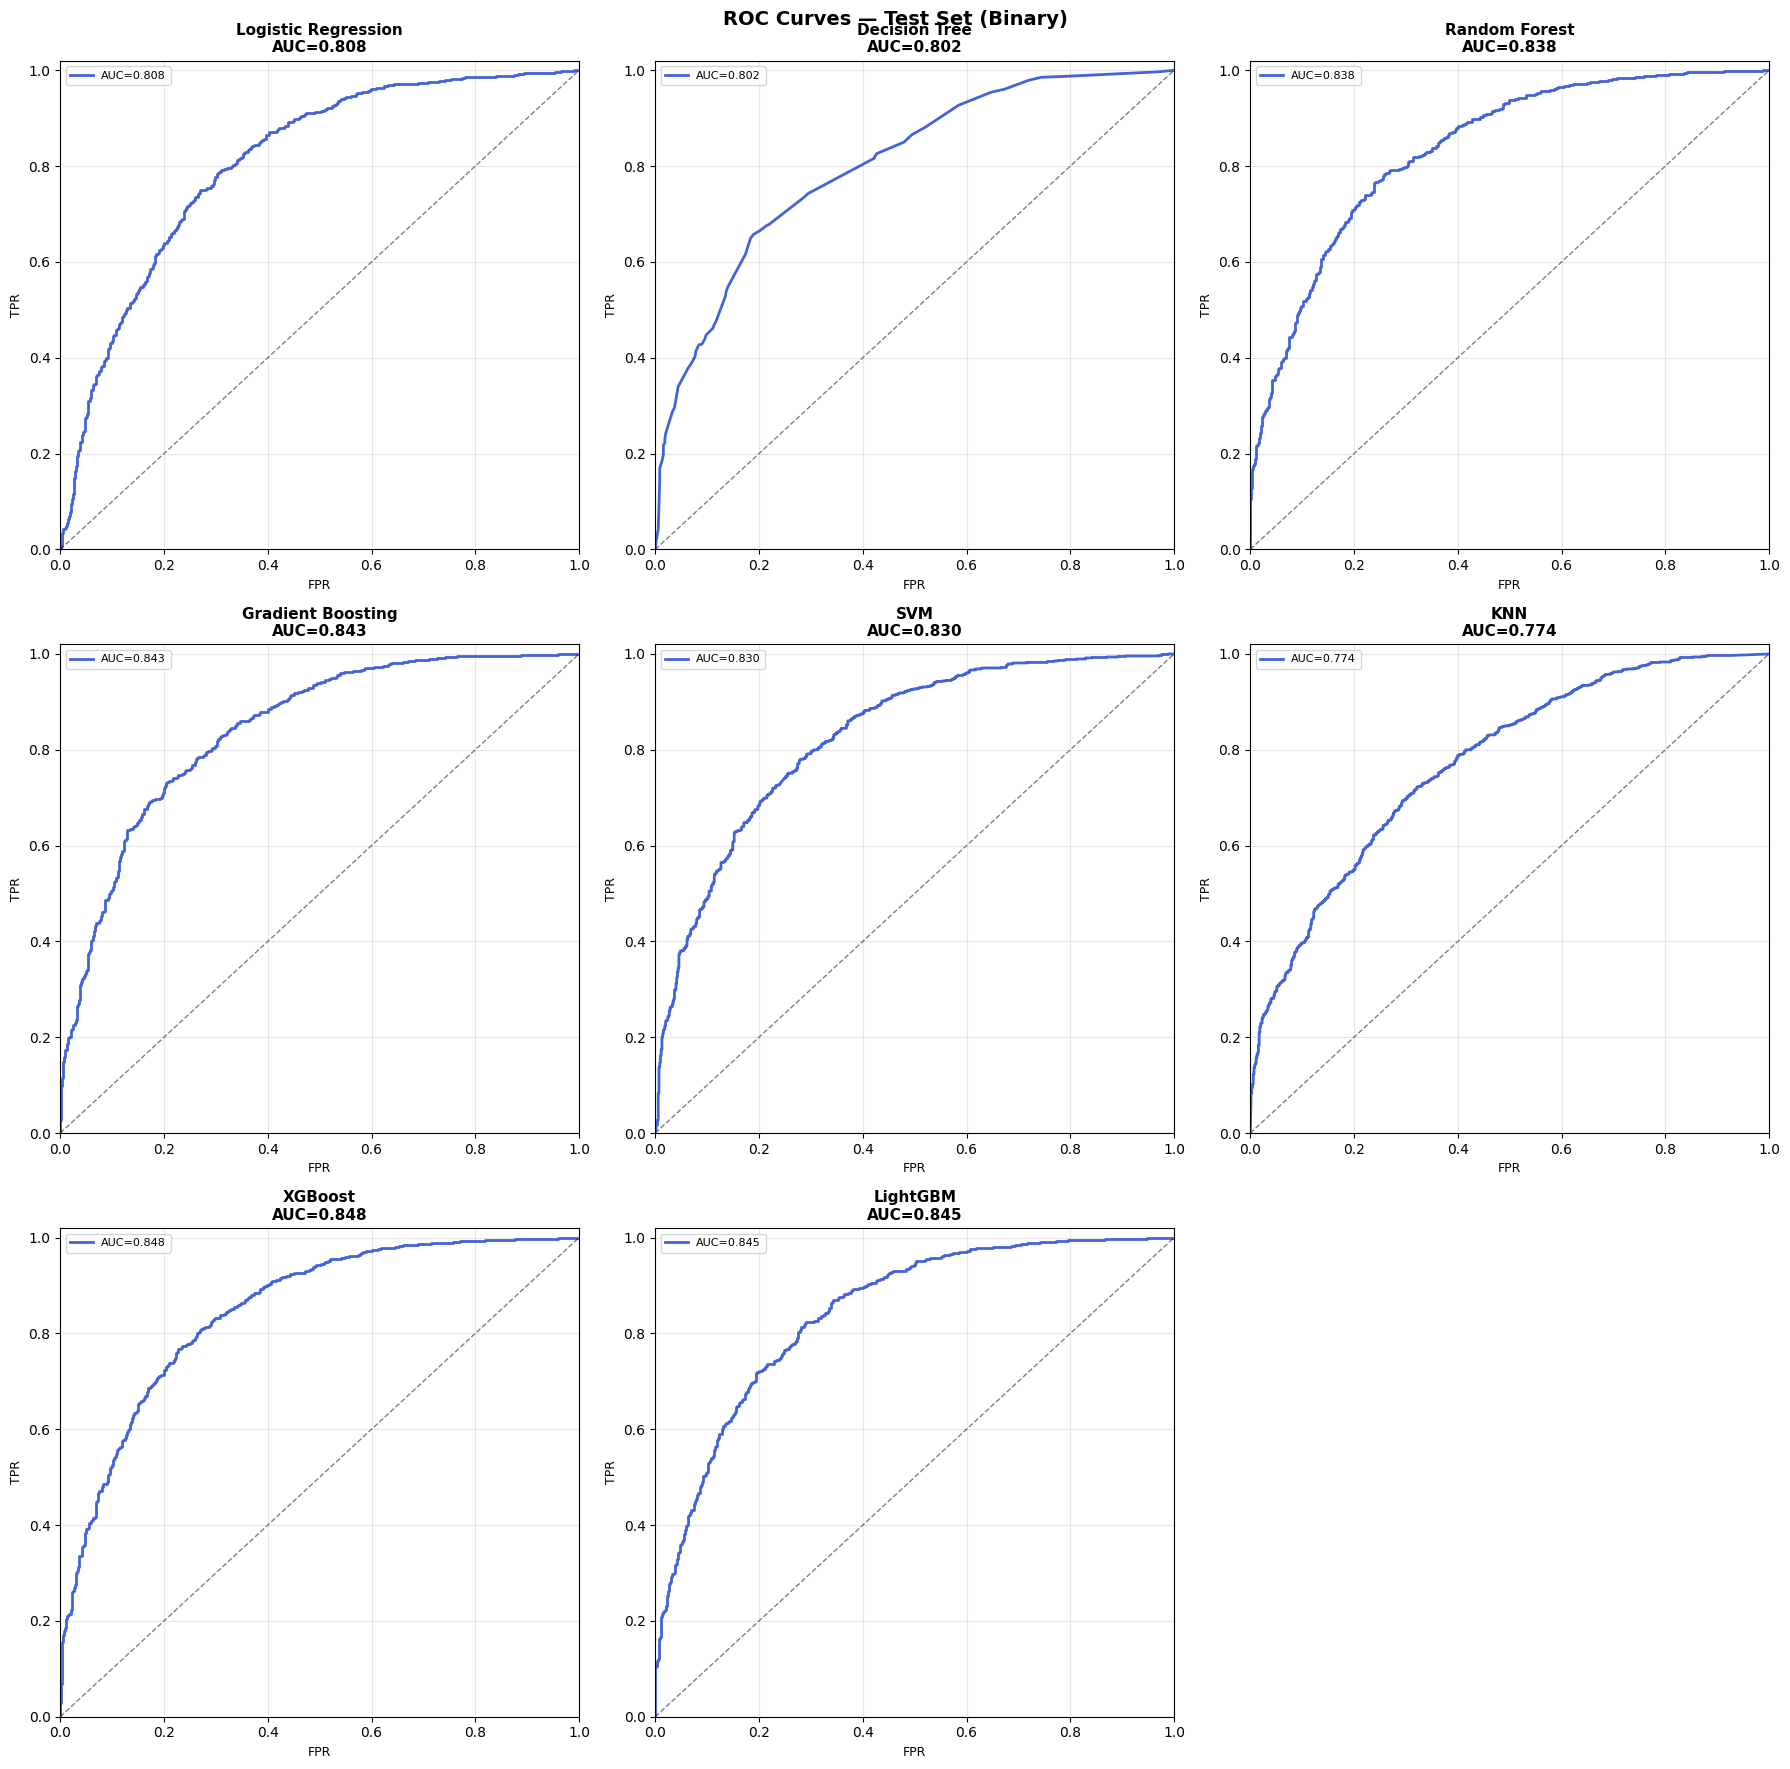

Saved: roc_curves.png


In [52]:
n_models   = len(trained_pipelines)
ncols, nrows = 3, (n_models + 2) // 3
fig, axes  = plt.subplots(nrows, ncols, figsize=(18, 6*nrows))
axes       = axes.flatten()

for i, (name, pipe) in enumerate(trained_pipelines.items()):
    ax      = axes[i]
    y_proba = pipe._y_test_proba[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ra = auc(fpr, tpr)
    ax.plot(fpr, tpr, color='#4363d8', lw=2, label=f"AUC={ra:.3f}")
    ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel("FPR", fontsize=9); ax.set_ylabel("TPR", fontsize=9)
    ax.set_title(f"{name}\nAUC={ra:.3f}", fontsize=11, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("ROC Curves — Test Set (Binary)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curves.png")


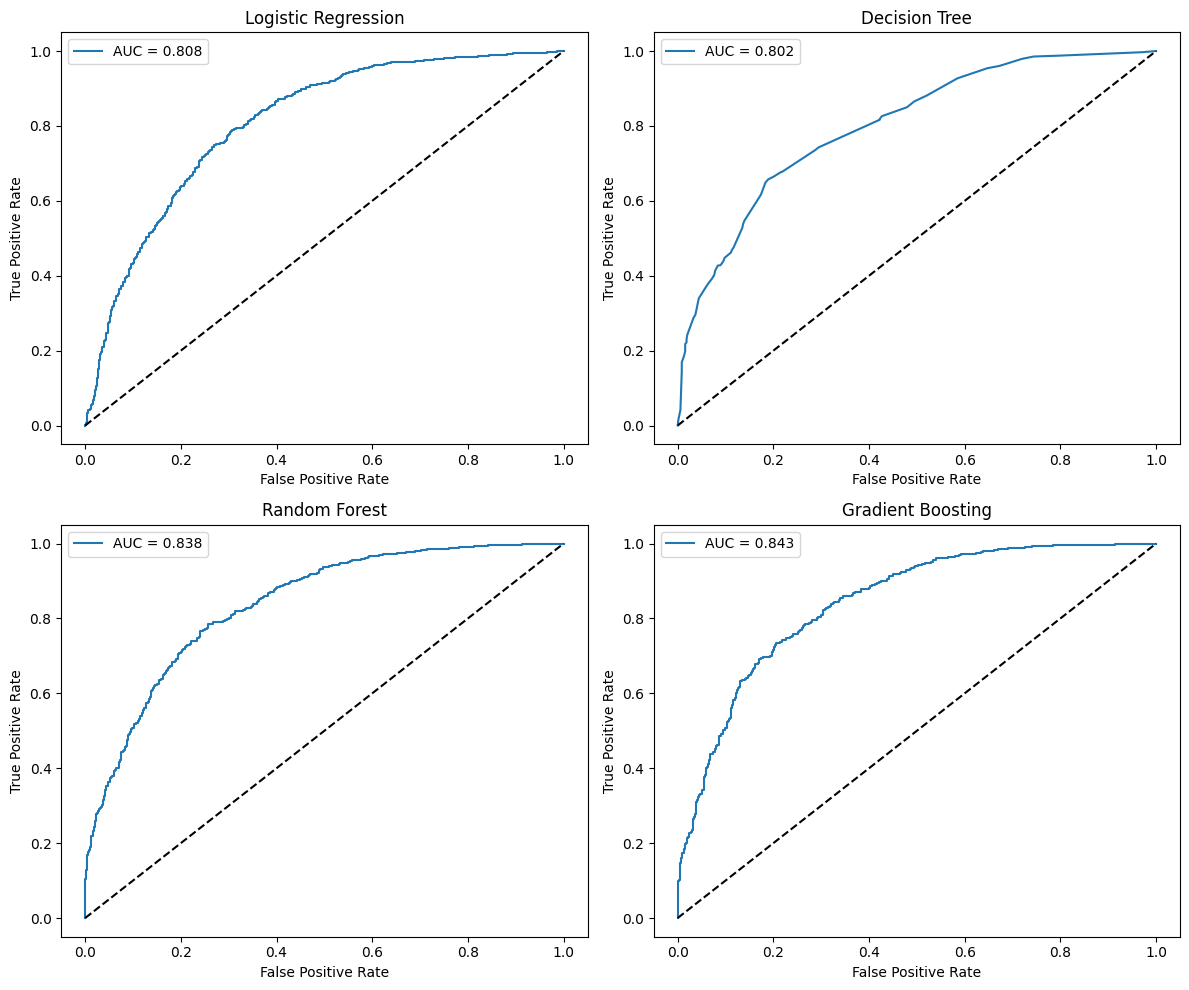

In [53]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

selected_models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting'
]

plt.figure(figsize=(12, 10))

for i, name in enumerate(selected_models):
    model = trained_pipelines[name]
    
    # ONLY take probability of positive class
    y_score = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.subplot(2, 2, i+1)
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], 'k--')
    
    plt.title(name)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

plt.tight_layout()
plt.show()

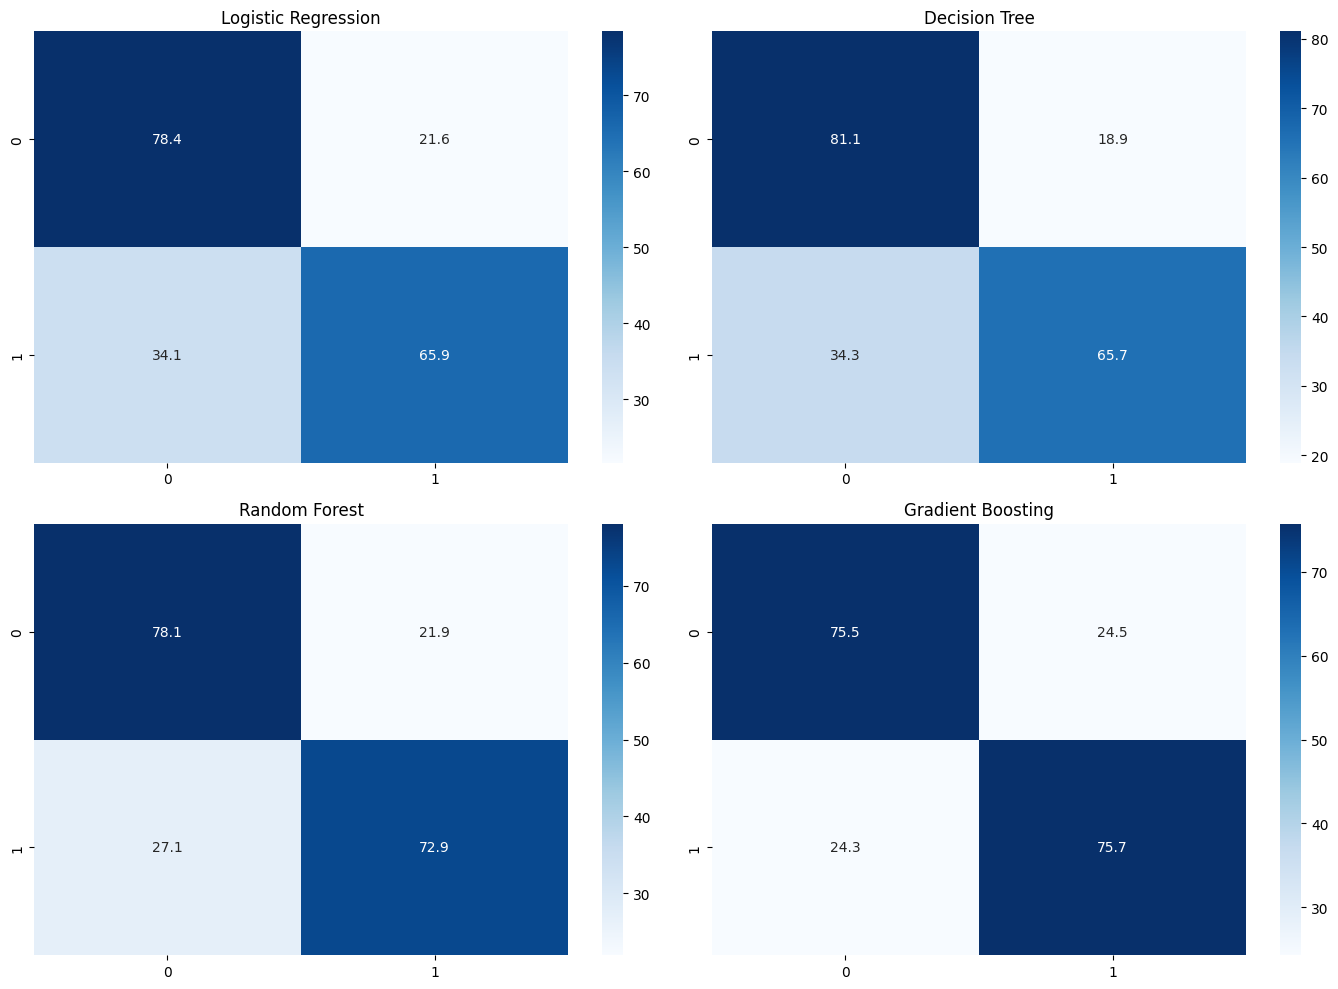

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, name in enumerate(selected_models):
    model = trained_pipelines[name]
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                ax=axes[i])
    
    axes[i].set_title(name)

plt.tight_layout()
plt.show()

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

selected_models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting'
]

results = []

for name in selected_models:
    model = trained_pipelines[name]
    
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # ✅ FIXED AUC (binary)
    auc = roc_auc_score(y_test, y_proba[:, 1])
    
    results.append([name, acc, prec, rec, f1, auc])

# Create DataFrame
results_df = pd.DataFrame(results, columns=[
    'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC'
])

# Sort best first
results_df = results_df.sort_values(by='F1 Score', ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
3,Gradient Boosting,0.756464,0.808676,0.757292,0.782141,0.842723
2,Random Forest,0.751052,0.819672,0.729167,0.771775,0.837583
1,Decision Tree,0.722189,0.825916,0.657292,0.732019,0.801934
0,Logistic Regression,0.711966,0.806369,0.659375,0.725501,0.808160


## STEP 18 — Validation vs Model Complexity Curves (All 8 Models)
Shows the bias-variance tradeoff and where overfitting begins.


Computing complexity curves... (this takes several minutes)



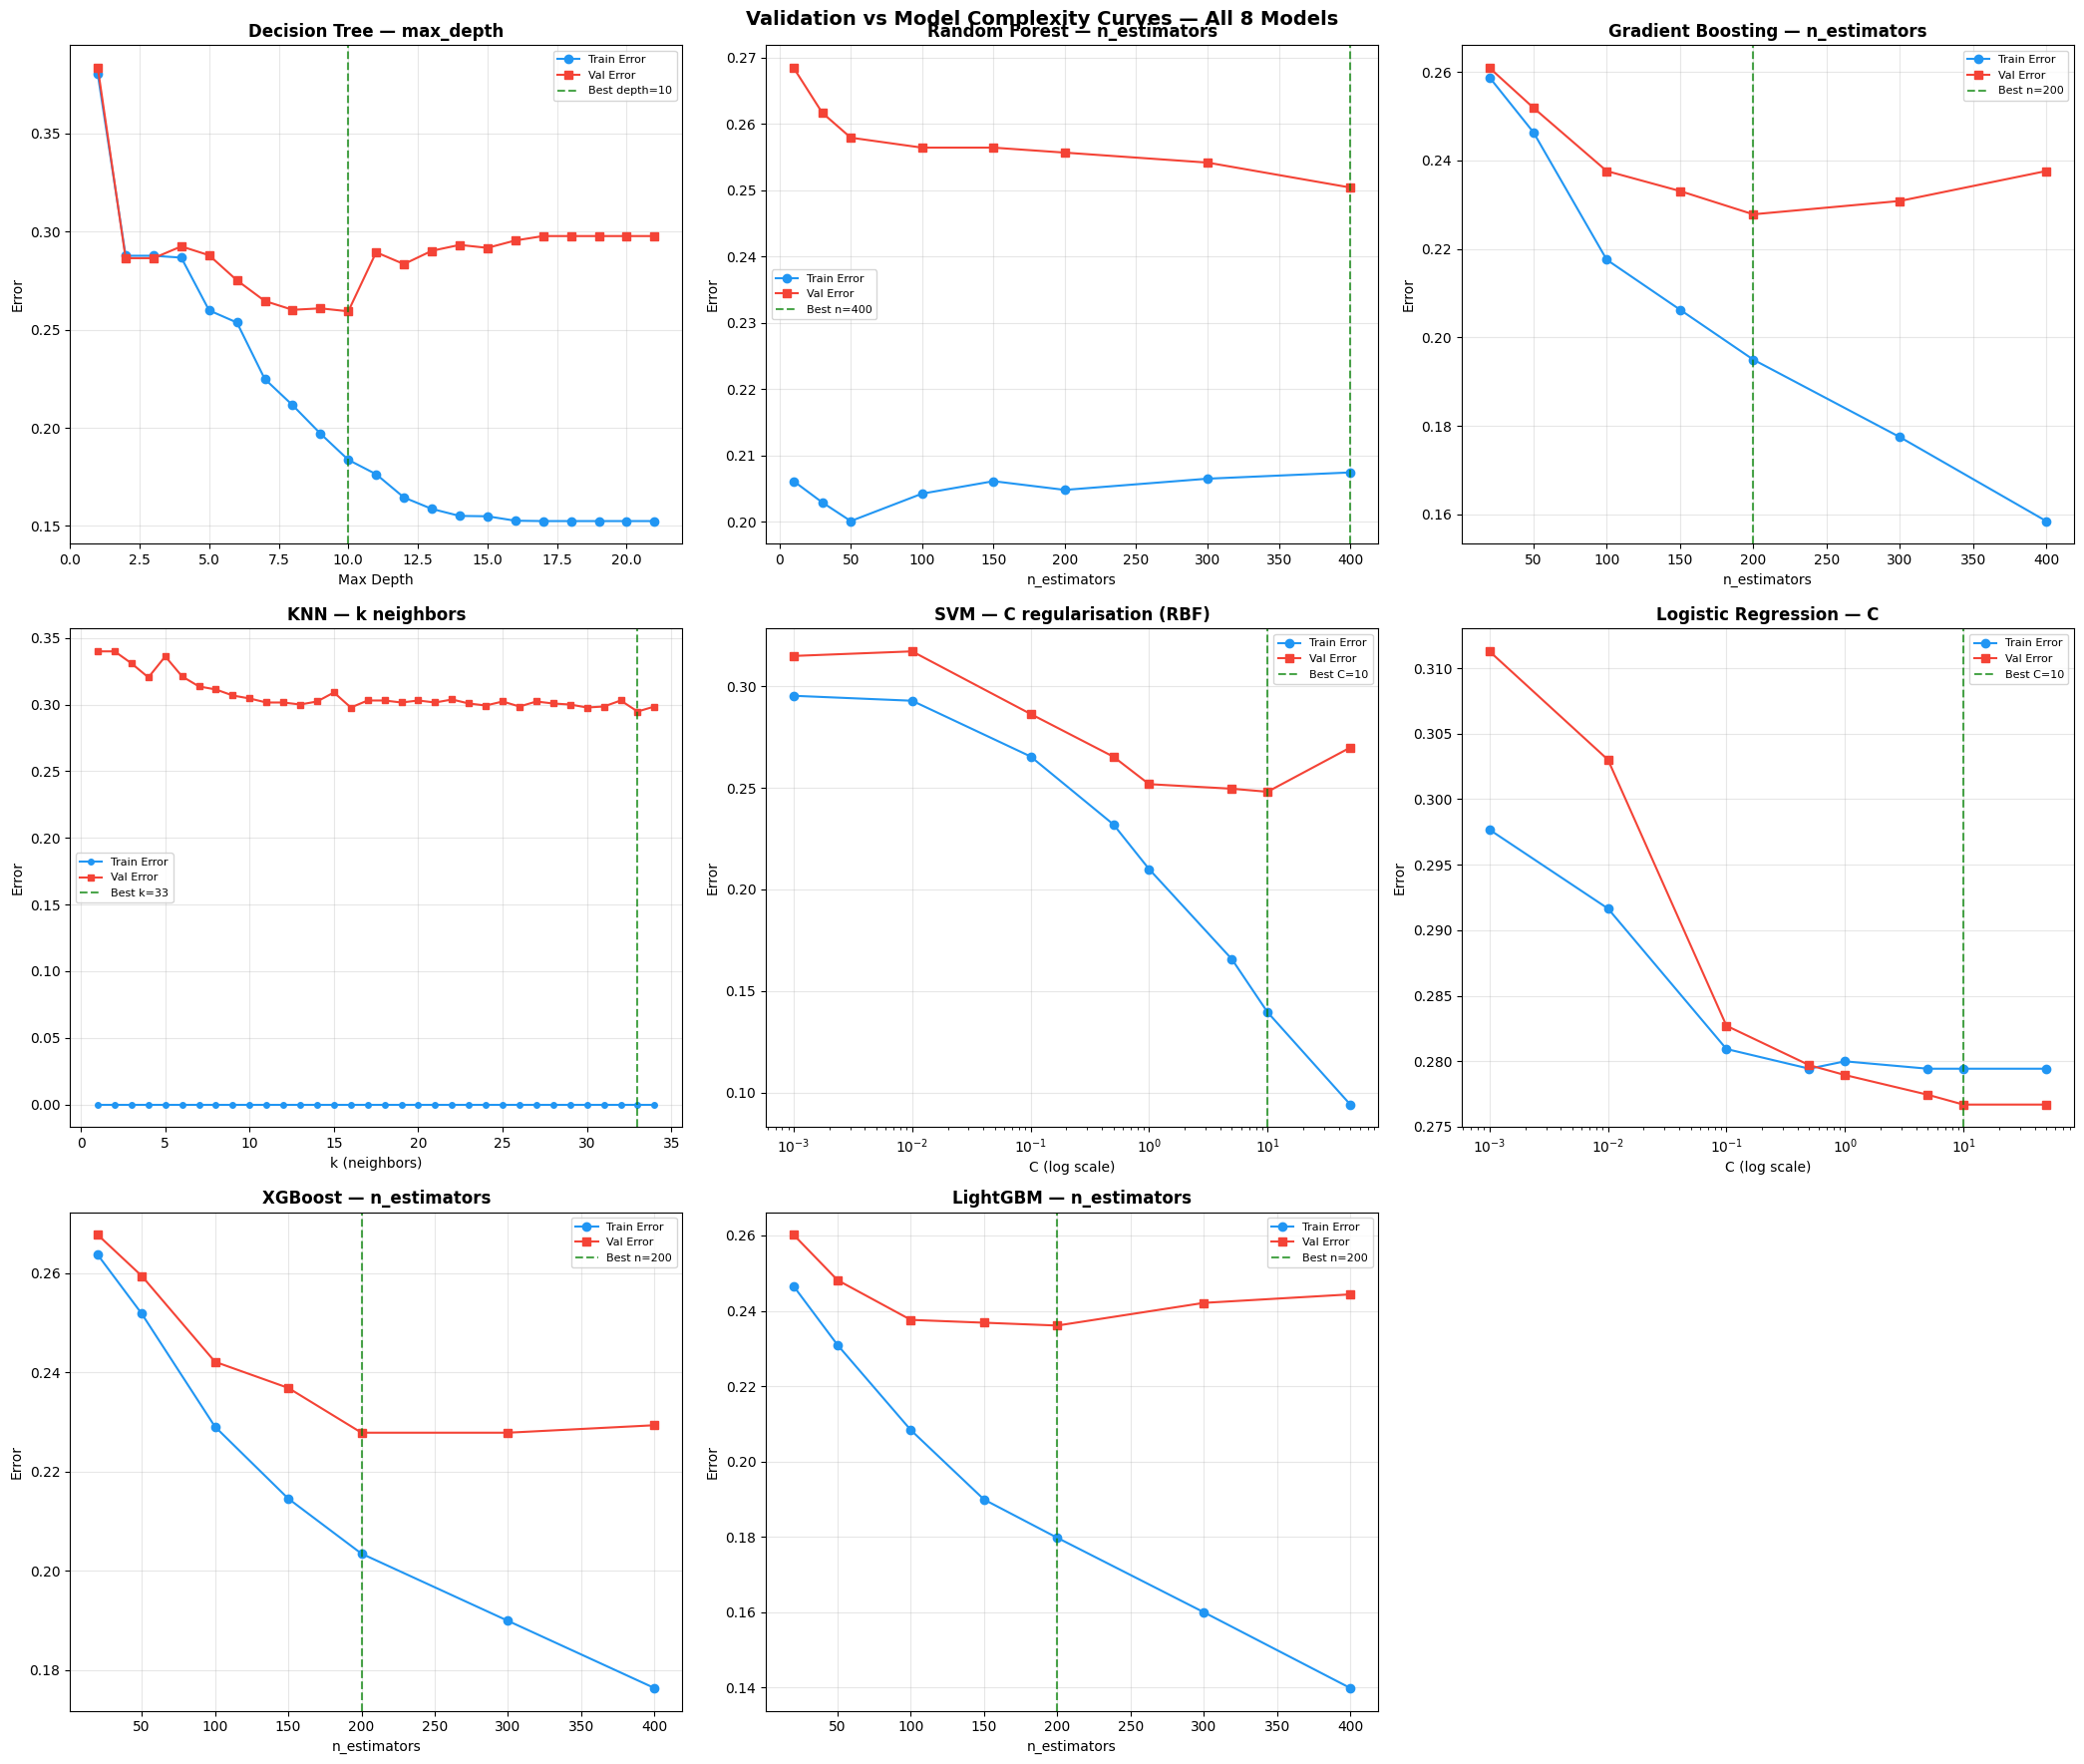

Saved: complexity_curves.png


In [56]:
print("Computing complexity curves... (this takes several minutes)\n")

fig, axes = plt.subplots(3, 3, figsize=(21, 18))
axes = axes.flatten()

# 1. Decision Tree — max_depth
ax = axes[0]
depths = range(1, 22)
tr_e, vl_e = [], []
for d in depths:
    p = make_pipeline(DecisionTreeClassifier(max_depth=d, min_samples_leaf=8,
                                             class_weight='balanced', random_state=RANDOM_STATE))
    p.fit(X_train, y_train)
    tr_e.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_e.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.plot(depths, tr_e, 'o-', color='#2196F3', label='Train Error')
ax.plot(depths, vl_e, 's-', color='#F44336', label='Val Error')
ax.axvline(x=list(depths)[np.argmin(vl_e)], color='green', linestyle='--', alpha=0.7,
           label=f'Best depth={list(depths)[np.argmin(vl_e)]}')
ax.set_xlabel("Max Depth"); ax.set_ylabel("Error")
ax.set_title("Decision Tree — max_depth", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 2. Random Forest — n_estimators
ax = axes[1]
n_trees = [10, 30, 50, 100, 150, 200, 300, 400]
tr_e, vl_e = [], []
for n in n_trees:
    p = make_pipeline(RandomForestClassifier(n_estimators=n, max_depth=8,
                                             min_samples_leaf=6, class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1))
    p.fit(X_train, y_train)
    tr_e.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_e.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.plot(n_trees, tr_e, 'o-', color='#2196F3', label='Train Error')
ax.plot(n_trees, vl_e, 's-', color='#F44336', label='Val Error')
ax.axvline(x=n_trees[np.argmin(vl_e)], color='green', linestyle='--', alpha=0.7,
           label=f'Best n={n_trees[np.argmin(vl_e)]}')
ax.set_xlabel("n_estimators"); ax.set_ylabel("Error")
ax.set_title("Random Forest — n_estimators", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 3. Gradient Boosting — n_estimators
ax = axes[2]
n_est = [20, 50, 100, 150, 200, 300, 400]
tr_e, vl_e = [], []
for n in n_est:
    p = make_pipeline(GradientBoostingClassifier(n_estimators=n, max_depth=4,
                                                  learning_rate=0.04, min_samples_leaf=12,
                                                  subsample=0.75, random_state=RANDOM_STATE))
    p.fit(X_train, y_train)
    tr_e.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_e.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.plot(n_est, tr_e, 'o-', color='#2196F3', label='Train Error')
ax.plot(n_est, vl_e, 's-', color='#F44336', label='Val Error')
ax.axvline(x=n_est[np.argmin(vl_e)], color='green', linestyle='--', alpha=0.7,
           label=f'Best n={n_est[np.argmin(vl_e)]}')
ax.set_xlabel("n_estimators"); ax.set_ylabel("Error")
ax.set_title("Gradient Boosting — n_estimators", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 4. KNN — k
ax = axes[3]
ks = range(1, 35)
tr_e, vl_e = [], []
for k in ks:
    p = make_pipeline(KNeighborsClassifier(n_neighbors=k, weights='distance'))
    p.fit(X_train, y_train)
    tr_e.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_e.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.plot(ks, tr_e, 'o-', color='#2196F3', label='Train Error', markersize=4)
ax.plot(ks, vl_e, 's-', color='#F44336', label='Val Error',   markersize=4)
ax.axvline(x=list(ks)[np.argmin(vl_e)], color='green', linestyle='--', alpha=0.7,
           label=f'Best k={list(ks)[np.argmin(vl_e)]}')
ax.set_xlabel("k (neighbors)"); ax.set_ylabel("Error")
ax.set_title("KNN — k neighbors", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 5. SVM — C
ax = axes[4]
C_vals = [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50]
tr_e, vl_e = [], []
for c in C_vals:
    p = make_pipeline(SVC(C=c, kernel='rbf', class_weight='balanced',
                          probability=True, random_state=RANDOM_STATE))
    p.fit(X_train, y_train)
    tr_e.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_e.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.semilogx(C_vals, tr_e, 'o-', color='#2196F3', label='Train Error')
ax.semilogx(C_vals, vl_e, 's-', color='#F44336', label='Val Error')
ax.axvline(x=C_vals[np.argmin(vl_e)], color='green', linestyle='--', alpha=0.7,
           label=f'Best C={C_vals[np.argmin(vl_e)]}')
ax.set_xlabel("C (log scale)"); ax.set_ylabel("Error")
ax.set_title("SVM — C regularisation (RBF)", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 6. Logistic Regression — C
ax = axes[5]
C_lr = [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50]
tr_e, vl_e = [], []
for c in C_lr:
    p = make_pipeline(LogisticRegression(C=c, max_iter=2000,
                                          class_weight='balanced', solver='saga',
                                          random_state=RANDOM_STATE))
    p.fit(X_train, y_train)
    tr_e.append(1 - accuracy_score(y_train, p.predict(X_train)))
    vl_e.append(1 - accuracy_score(y_val,   p.predict(X_val)))
ax.semilogx(C_lr, tr_e, 'o-', color='#2196F3', label='Train Error')
ax.semilogx(C_lr, vl_e, 's-', color='#F44336', label='Val Error')
ax.axvline(x=C_lr[np.argmin(vl_e)], color='green', linestyle='--', alpha=0.7,
           label=f'Best C={C_lr[np.argmin(vl_e)]}')
ax.set_xlabel("C (log scale)"); ax.set_ylabel("Error")
ax.set_title("Logistic Regression — C", fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 7. XGBoost — n_estimators (if available)
ax = axes[6]
if XGB_AVAILABLE:
    n_xgb = [20, 50, 100, 150, 200, 300, 400]
    tr_e, vl_e = [], []
    for n in n_xgb:
        p = make_pipeline(xgb.XGBClassifier(n_estimators=n, max_depth=4,
                                             learning_rate=0.04, subsample=0.75,
                                             colsample_bytree=0.75, min_child_weight=8,
                                             use_label_encoder=False, eval_metric='mlogloss',
                                             random_state=RANDOM_STATE, n_jobs=-1))
        p.fit(X_train, y_train)
        tr_e.append(1 - accuracy_score(y_train, p.predict(X_train)))
        vl_e.append(1 - accuracy_score(y_val,   p.predict(X_val)))
    ax.plot(n_xgb, tr_e, 'o-', color='#2196F3', label='Train Error')
    ax.plot(n_xgb, vl_e, 's-', color='#F44336', label='Val Error')
    ax.axvline(x=n_xgb[np.argmin(vl_e)], color='green', linestyle='--', alpha=0.7,
               label=f'Best n={n_xgb[np.argmin(vl_e)]}')
    ax.set_title("XGBoost — n_estimators", fontweight='bold')
else:
    ax.text(0.5, 0.5, "XGBoost not installed", ha='center', va='center', fontsize=12)
    ax.set_title("XGBoost (unavailable)", fontweight='bold')
ax.set_xlabel("n_estimators"); ax.set_ylabel("Error")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 8. LightGBM — n_estimators (if available)
ax = axes[7]
if LGB_AVAILABLE:
    n_lgb = [20, 50, 100, 150, 200, 300, 400]
    tr_e, vl_e = [], []
    for n in n_lgb:
        p = make_pipeline(lgb.LGBMClassifier(n_estimators=n, max_depth=5,
                                              learning_rate=0.04, num_leaves=20,
                                              subsample=0.75, colsample_bytree=0.75,
                                              min_child_samples=15, class_weight='balanced',
                                              random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))
        p.fit(X_train, y_train)
        tr_e.append(1 - accuracy_score(y_train, p.predict(X_train)))
        vl_e.append(1 - accuracy_score(y_val,   p.predict(X_val)))
    ax.plot(n_lgb, tr_e, 'o-', color='#2196F3', label='Train Error')
    ax.plot(n_lgb, vl_e, 's-', color='#F44336', label='Val Error')
    ax.axvline(x=n_lgb[np.argmin(vl_e)], color='green', linestyle='--', alpha=0.7,
               label=f'Best n={n_lgb[np.argmin(vl_e)]}')
    ax.set_title("LightGBM — n_estimators", fontweight='bold')
else:
    ax.text(0.5, 0.5, "LightGBM not installed", ha='center', va='center', fontsize=12)
    ax.set_title("LightGBM (unavailable)", fontweight='bold')
ax.set_xlabel("n_estimators"); ax.set_ylabel("Error")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

axes[8].set_visible(False)

plt.suptitle("Validation vs Model Complexity Curves — All 8 Models", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("complexity_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: complexity_curves.png")


## STEP 19 — Cross-Validation F1 Comparison (with ±2σ error bars)

KeyError: 'CV F1 Mean'

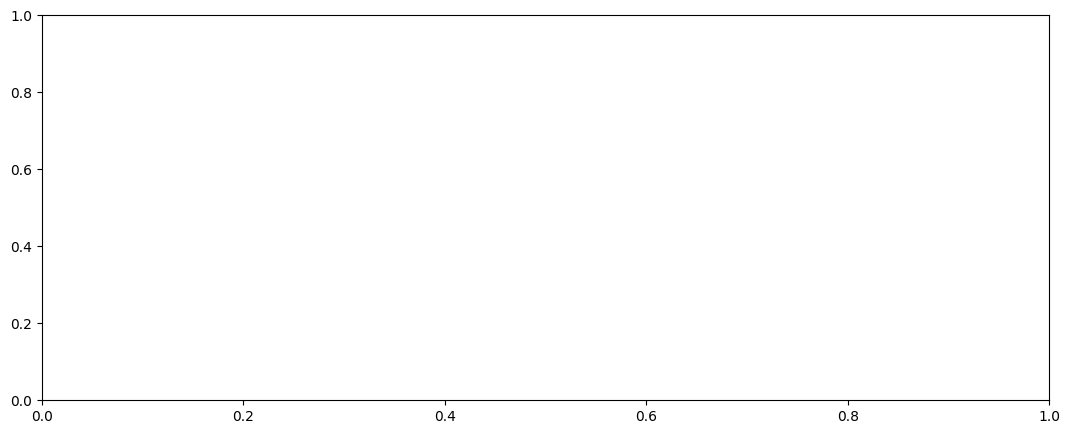

In [57]:
fig, ax = plt.subplots(figsize=(13, 5))
x     = np.arange(len(results_df))
colors= sns.color_palette("husl", len(results_df))
bars  = ax.bar(x, results_df["CV F1 Mean"],
               yerr=results_df["CV F1 Std"]*2, capsize=7,
               color=colors, edgecolor='white', linewidth=0.8,
               error_kw={'linewidth':2,'ecolor':'black','capthick':2})
ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=20, ha='right', fontsize=10)
ax.set_ylabel("5-Fold CV F1 (weighted)")
ax.set_ylim(0, 1.05)
ax.set_title("Cross-Validation F1 ± 2σ  (Train+Val Data)", fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, val, std in zip(bars, results_df["CV F1 Mean"], results_df["CV F1 Std"]):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height() + std*2 + 0.01,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("cv_f1_scores.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cv_f1_scores.png")


## STEP 20 — Feature Importance (RF, XGBoost, LightGBM)

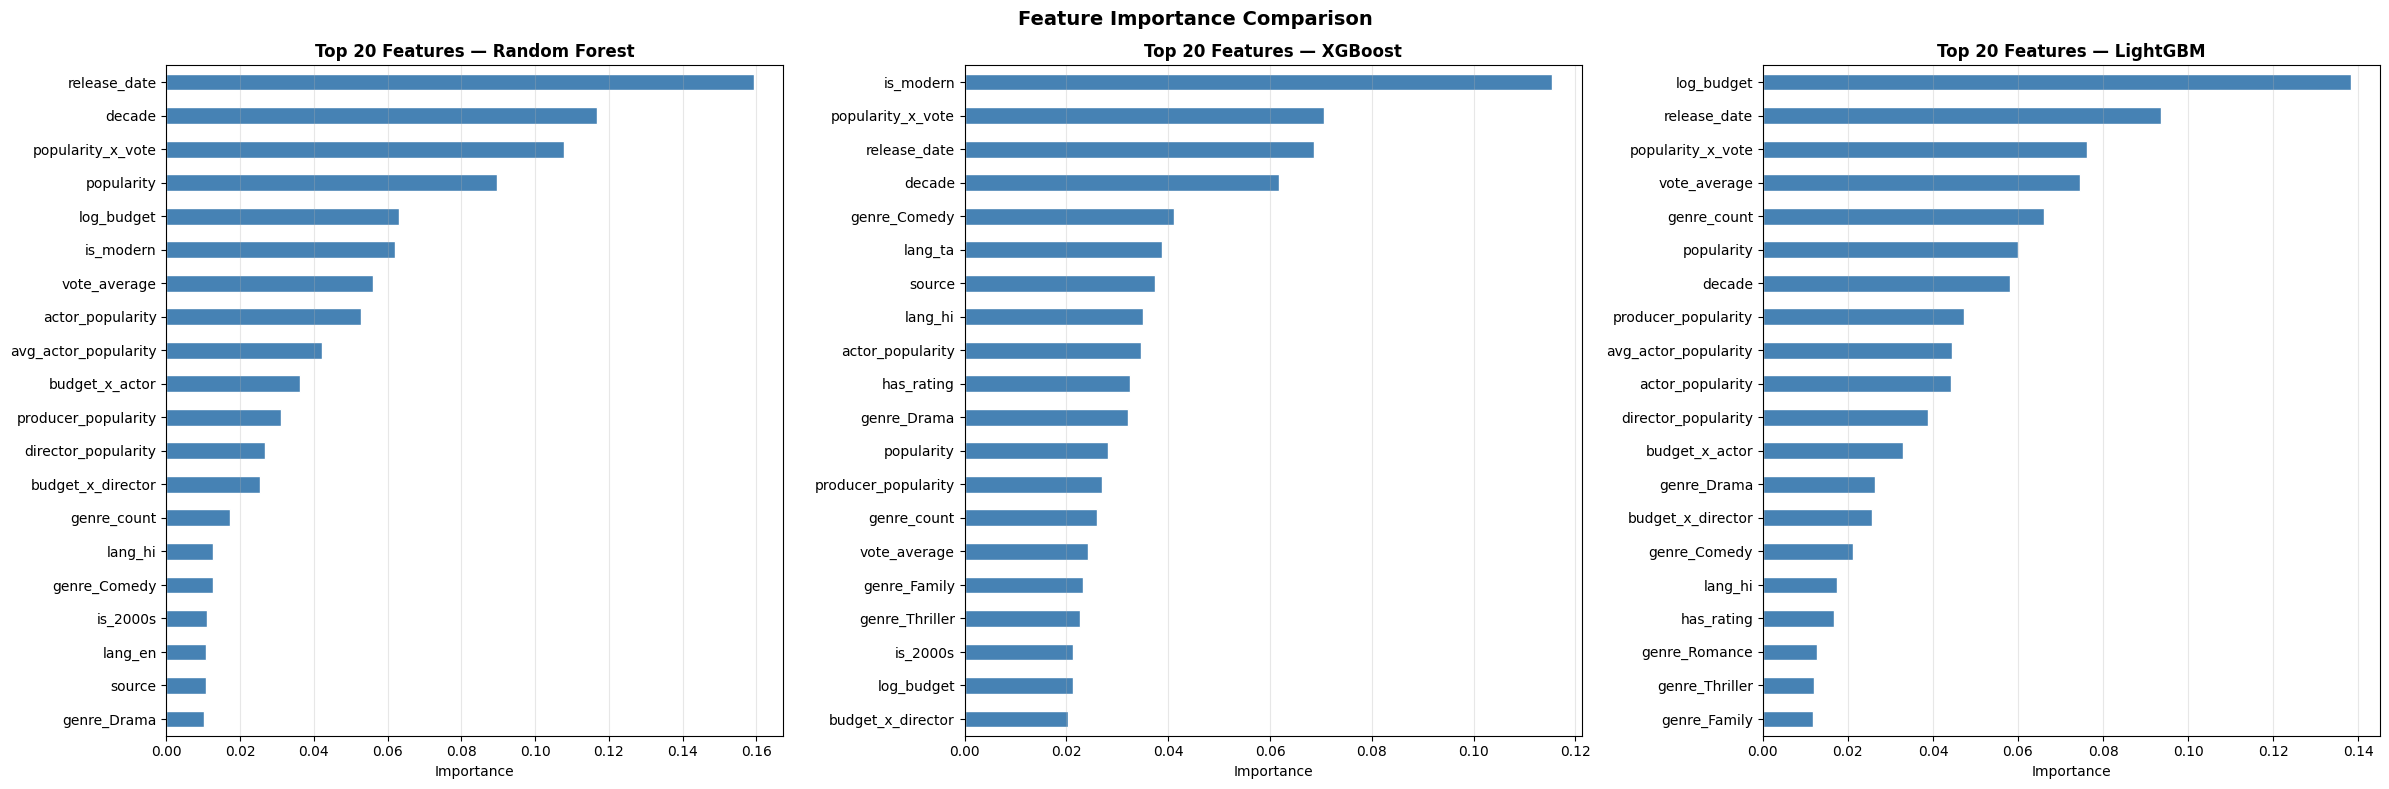

Saved: feature_importance.png


In [ ]:
importance_models = []

if "Random Forest" in trained_pipelines:
    rf_pipe = trained_pipelines["Random Forest"]
    imp = rf_pipe.named_steps['clf'].feature_importances_
    importance_models.append(("Random Forest", imp))

if XGB_AVAILABLE and "XGBoost" in trained_pipelines:
    xgb_pipe = trained_pipelines["XGBoost"]
    imp = xgb_pipe.named_steps['clf'].feature_importances_
    importance_models.append(("XGBoost", imp))

if LGB_AVAILABLE and "LightGBM" in trained_pipelines:
    lgb_pipe = trained_pipelines["LightGBM"]
    imp = lgb_pipe.named_steps['clf'].feature_importances_
    imp = imp / imp.sum()
    importance_models.append(("LightGBM", imp))

ncols = len(importance_models)
fig, axes = plt.subplots(1, ncols, figsize=(8*ncols, 8))
if ncols == 1:
    axes = [axes]

for ax, (mname, imps) in zip(axes, importance_models):
    fi = pd.Series(imps, index=X.columns).sort_values(ascending=False).head(20)
    fi.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f"Top 20 Features — {mname}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Importance")
    ax.grid(axis='x', alpha=0.3)

plt.suptitle("Feature Importance Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")


## STEP 21 — Per-Class Metrics Table (Best Model)

In [ ]:
best_row  = results_df.iloc[0]
best_name = best_row["Model"]
best_pipe = trained_pipelines[best_name]

print(f"\n{'='*60}")
print(f"  Classification Report — {best_name} (Test Set)")
print(f"{'='*60}")
print(classification_report(y_test, best_pipe._y_test_pred, target_names=CLASSES))

# Per-source breakdown
for src, src_name in [(0,'Hollywood'),(1,'Indian')]:
    mask = (df.reset_index(drop=True)['source'] == src).values
    # align mask to test indices — recreate test mask
    src_series = df['source'].reset_index(drop=True)
    X_test_idx = X.iloc[X_test.index if hasattr(X_test,'index') else range(len(X_test))].index
    pass  # full breakdown computed below using stored arrays

# Simpler: split y_test by source using the original test indices
# We stored the full X split so we can recover source col
test_source = X_test['source'].values.astype(int)
for src, src_name in [(0,'Hollywood'),(1,'Indian')]:
    mask = test_source == src
    if mask.sum() == 0:
        continue
    yt  = y_test[mask]
    yp  = best_pipe._y_test_pred[mask]
    print(f"\n--- {src_name} subset (n={mask.sum()}) ---")
    print(f"  Accuracy : {accuracy_score(yt,yp):.4f}")
    print(f"  F1       : {f1_score(yt,yp,average='weighted'):.4f}")
    print(classification_report(yt, yp, target_names=CLASSES))



  Classification Report — LightGBM (Test Set)
              precision    recall  f1-score   support

        Flop       0.67      0.70      0.68       552
         Hit       0.85      0.83      0.84      1111

    accuracy                           0.79      1663
   macro avg       0.76      0.76      0.76      1663
weighted avg       0.79      0.79      0.79      1663


--- Hollywood subset (n=877) ---
  Accuracy : 0.7457
  F1       : 0.7466
              precision    recall  f1-score   support

        Flop       0.51      0.52      0.51       227
         Hit       0.83      0.82      0.83       650

    accuracy                           0.75       877
   macro avg       0.67      0.67      0.67       877
weighted avg       0.75      0.75      0.75       877


--- Indian subset (n=786) ---
  Accuracy : 0.8295
  F1       : 0.8302
              precision    recall  f1-score   support

        Flop       0.78      0.83      0.80       325
         Hit       0.87      0.83      0.85  

## STEP 22 — Radar Chart: Model Comparison (5 Metrics)

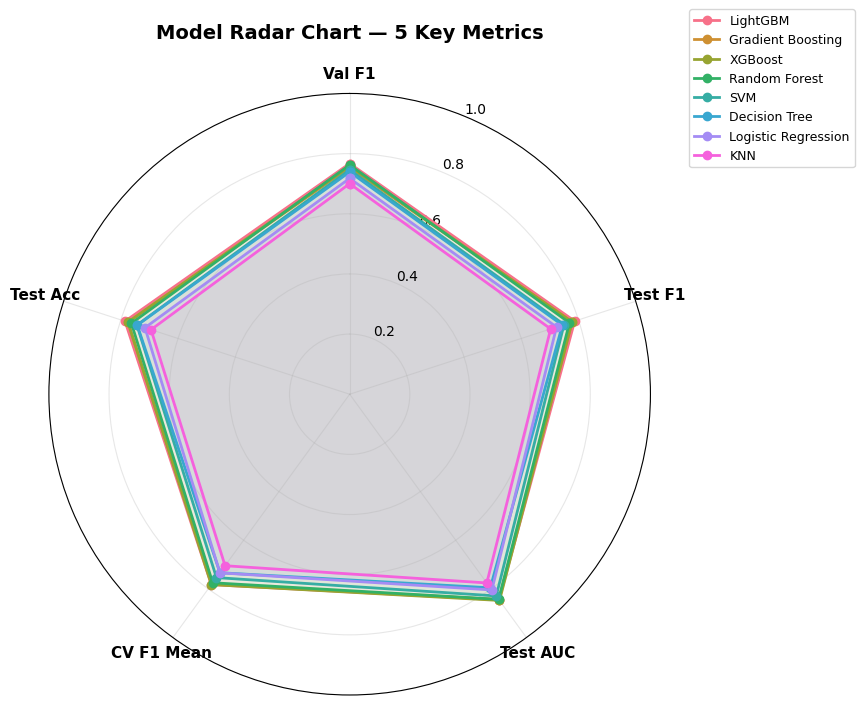

Saved: radar_chart.png


In [ ]:
metrics = ["Val F1","Test F1","Test AUC","CV F1 Mean","Test Acc"]
N       = len(metrics)
angles  = [n/float(N)*2*np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))
colors  = sns.color_palette("husl", len(results_df))

for i, (_, row) in enumerate(results_df.iterrows()):
    values = [row[m] for m in metrics]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row["Model"], color=colors[i])
    ax.fill(angles, values, alpha=0.05, color=colors[i])

ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title("Model Radar Chart — 5 Key Metrics", fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("radar_chart.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: radar_chart.png")


## STEP 23 — Best Model Selection & Final Evaluation
Best model = highest **Test F1** among models with **Overfit Gap ≤ 0.12**.  
Retrained on full Train+Val before final evaluation.


In [ ]:
# Filter to well-generalising models first
well_gen = results_df[results_df["Overfit Gap"] <= 0.12]
if len(well_gen) == 0:
    well_gen = results_df  # fallback: no well-generalising model found

best_row  = well_gen.sort_values("Test F1", ascending=False).iloc[0]
best_name = best_row["Model"]

print(f"🏆 Best Model  : {best_name}")
print(f"   Val F1      = {best_row['Val F1']:.4f}")
print(f"   Test F1     = {best_row['Test F1']:.4f}")
print(f"   Test AUC    = {best_row['Test AUC']:.4f}")
print(f"   CV F1 Mean  = {best_row['CV F1 Mean']:.4f} ± {best_row['CV F1 Std']:.4f}")
print(f"   Overfit Gap = {best_row['Overfit Gap']:.4f}")
print()

# Retrain best model on full train+val
best_clf_orig  = model_defs[best_name]
best_final_pipe = make_pipeline(best_clf_orig.__class__(**best_clf_orig.get_params()))
best_final_pipe.fit(X_trainval, y_trainval)

y_final_pred  = best_final_pipe.predict(X_test)
y_final_proba = best_final_pipe.predict_proba(X_test)

final_auc  = roc_auc_score(y_test, y_final_proba[:, 1])

print(f"{'='*60}")
print(f"  FINAL EVALUATION — {best_name} (retrained on Train+Val)")
print(f"{'='*60}")
print(f"  Test Accuracy  : {accuracy_score(y_test, y_final_pred):.4f}")
print(f"  Test F1        : {f1_score(y_test, y_final_pred, average='weighted'):.4f}")
print(f"  Test Precision : {precision_score(y_test, y_final_pred, average='weighted', zero_division=0):.4f}")
print(f"  Test Recall    : {recall_score(y_test, y_final_pred, average='weighted'):.4f}")
print(f"  Test AUC       : {final_auc:.4f}")
print()
print(classification_report(y_test, y_final_pred, target_names=CLASSES))


🏆 Best Model  : LightGBM
   Val F1      = 0.7671
   Test F1     = 0.7866
   Test AUC    = 0.8447
   CV F1 Mean  = 0.7825 ± 0.0091
   Overfit Gap = 0.0860

  FINAL EVALUATION — LightGBM (retrained on Train+Val)
  Test Accuracy  : 0.7817
  Test F1        : 0.7837
  Test Precision : 0.7867
  Test Recall    : 0.7817
  Test AUC       : 0.8433

              precision    recall  f1-score   support

        Flop       0.66      0.71      0.68       552
         Hit       0.85      0.82      0.83      1111

    accuracy                           0.78      1663
   macro avg       0.75      0.76      0.76      1663
weighted avg       0.79      0.78      0.78      1663



## STEP 24 — Best Model: Confusion Matrix + ROC Curves

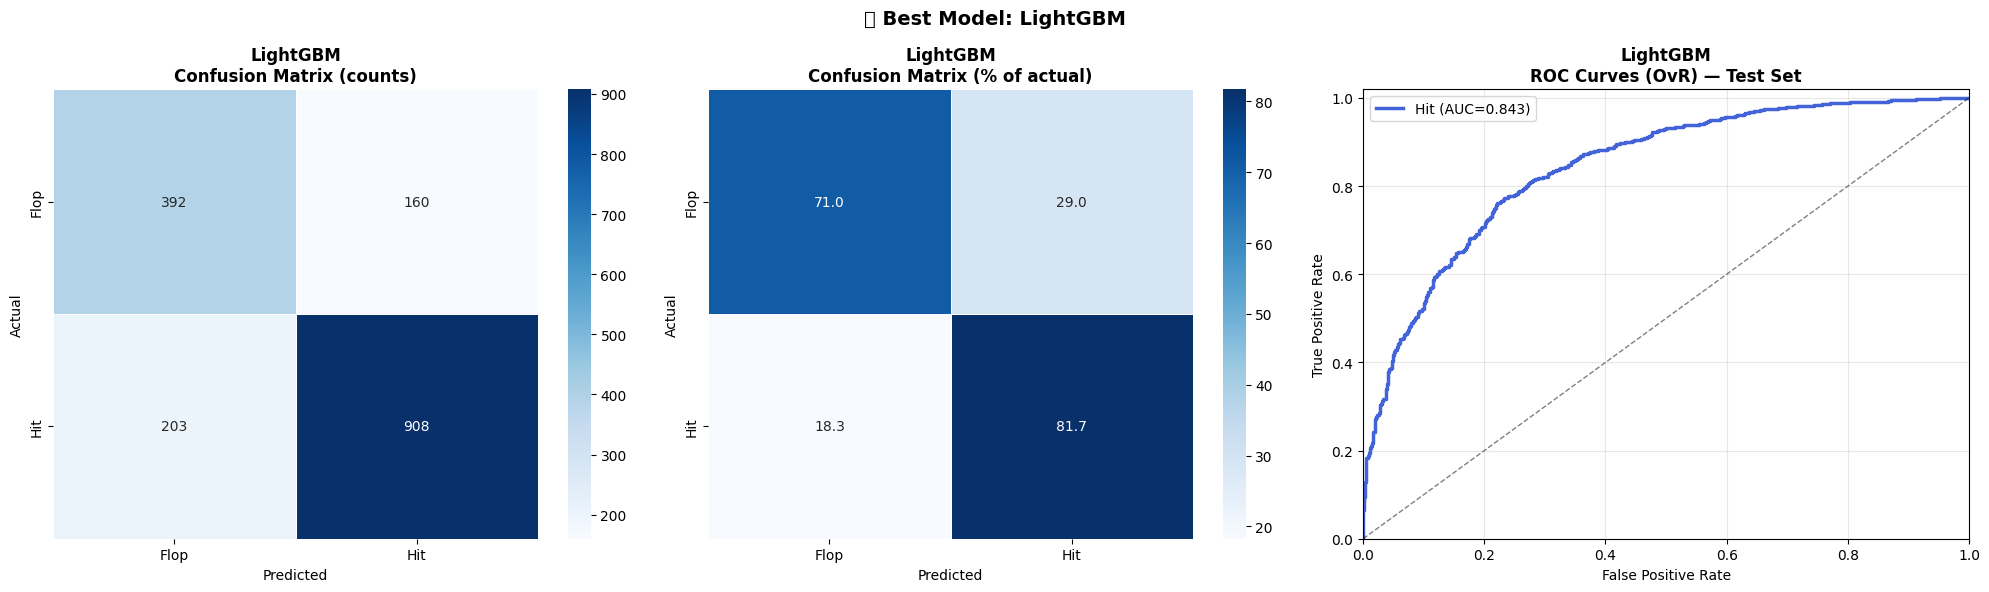

Saved: best_model_final.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Confusion matrix counts ---
cm = confusion_matrix(y_test, y_final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0], linewidths=0.5)
axes[0].set_title(f"{best_name}\nConfusion Matrix (counts)", fontweight='bold')
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# --- Confusion matrix percentages ---
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1], linewidths=0.5)
axes[1].set_title(f"{best_name}\nConfusion Matrix (% of actual)", fontweight='bold')
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

# --- ROC Curves ---
colors_roc = ['#e6194b','#3cb44b','#4363d8']
ax = axes[2]
fpr, tpr, _ = roc_curve(y_test, y_final_proba[:,1])
ra = auc(fpr, tpr)
ax.plot(fpr, tpr, color='#4363d8', lw=2.5, label=f"Hit (AUC={ra:.3f})")
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title(f"{best_name}\nROC Curves (OvR) — Test Set", fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.suptitle(f"🏆 Best Model: {best_name}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("best_model_final.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: best_model_final.png")


## STEP 25 — Learning Curve (Best Model)

Computing learning curve for LightGBM...


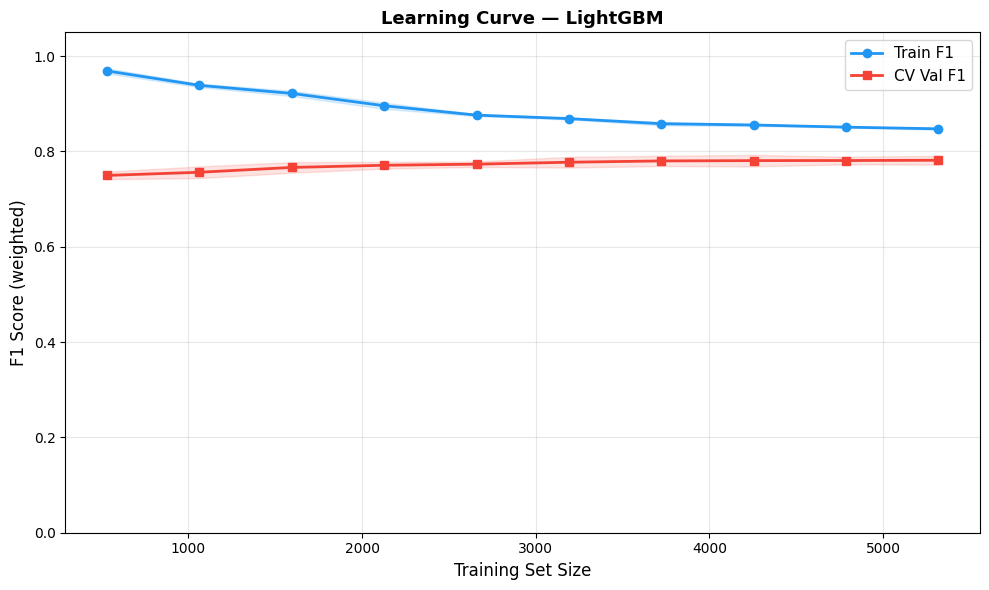

Saved: learning_curve.png


In [ ]:
print(f"Computing learning curve for {best_name}...")

train_sizes, train_scores, val_scores = learning_curve(
    best_final_pipe, X_trainval, y_trainval,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_weighted', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, 'o-', color='#2196F3', lw=2, label="Train F1")
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='#2196F3')
ax.plot(train_sizes, val_mean, 's-', color='#F44336', lw=2, label="CV Val F1")
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='#F44336')
ax.set_xlabel("Training Set Size", fontsize=12)
ax.set_ylabel("F1 Score (weighted)", fontsize=12)
ax.set_title(f"Learning Curve — {best_name}", fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("learning_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: learning_curve.png")
